# Project-ShopAssist AI

## Part 1: Introduction

#### **What you have learnt till now**

So far you have learnt how to make LLM API calls in Python. In particular, you worked with OpenAI's GPT 3.5 models and the `Chat Completion API` to build a simple AI tutor.

<br>

Next, you went over some principles, techniques, and tactics for prompt engineering.
The two main principles of writing a good prompt:
1.  Providing clear instructions,
2.  Enhancing LLM reasoning capabilities.

Under providing clear instructions, you learnt how to structure the body of a prompt through 5 components - **Task, Role, Context, Guidelines and Output Format**.

You also understood that providing a very clear syntax and conditioning on good performance can get you closer to the desired output.

<br>

Next, under enhancing LLM reasoning capabilities, you learnt two specific techniques -
(i) Chain-of-Thought prompting,
(ii) Few-Shot prompting.

Under chain-of-thought prompting, you essentially enable the LLM to work through the solution step-by-step and in few-shot prompting, you provide relevant examples of how you want the outputs to look like. So now you could structure your prompts into proper components and provide clear chain-of-thought instructions along with relevant examples of ideal inputs and outputs.

You also learnt some advanced prompting techniques like self-consistency and ReAct prompting. Self-consistency is basically the technique where you ensemble multiple attempts and select the most consistent output out of them. And in ReAct prompting, you enable the LLM to reason out a scenario and act based on some examples.

<br>

Finally, you looked at some examples of how you can design LLM-based systems. Apart from prompting techniques, you understood that designing a LLM-based system also requires a safe design, i.e., the capabilities to detect and respond to unsafe user queries and prompt injections. You looked at the moderation API offered by OpenAI that can help you design such safer systems.

With all of these learnings, let’s now get started on designing our first LLM application - ShopAssist AI.


#### Project Background

In today's digital age, online shopping has become the go-to option for many consumers. However, the overwhelming number of choices and the lack of personalized assistance can make the shopping experience daunting. To address this, we have developed **ShopAssist AI, a chatbot that combines the power of large language models and rule-based functions to ensure accurate and reliable information delivery**.


#### Problem Statement

*Given a dataset containing information about laptops (product names, specifications, descriptions, etc.), build a chatbot that parses the dataset and provides accurate laptop recommendations based on user requirements*.


You can load the data and see it here.

You can download the data from [here](https://cdn.upgrad.com/uploads/production/c85f3fdd-b29f-4c47-9e87-99bbda0fd233/laptop_data.csv) or uncomment the code below to download the file.

In [6]:
# Import the libraries
import pandas as pd
from IPython.display import display
# Set the display width to control the output width
pd.set_option('display.width', 100)
# Read the dataset and read the Laptop Dataset
df = pd.read_csv("D:\Shop Assist\laptop_data.csv")
df

,Brand,Model Name,Core,CPU Manufacturer,Clock Speed,RAM Size,Storage Type,Display Type,Display Size,Graphics Processor,Screen Resolution,OS,Laptop Weight,Special Features,Warranty,Average Battery Life,Price,Description
0,Dell,Inspiron,i5,Intel,2.4 GHz,8GB,SSD,LCD,"15.6""",Intel UHD,1920x1080,Windows 10,2.5 kg,Backlit Keyboard,1 year,6 hours,"35,000",The Dell Inspiron is a versatile laptop that c...
1,MSI,GL65,i7,Intel,2.6 GHz,16GB,HDD+SSD,IPS,"15.6""",NVIDIA GTX,1920x1080,Windows 10,2.3 kg,RGB Keyboard,2 years,4 hours,"55,000",The MSI GL65 is a high-performance laptop desi...
2,HP,EliteBook,i7,Intel,2.8 GHz,16GB,SSD,LED,"14""",Intel UHD,1920x1080,Windows 11,1.5 kg,Fingerprint Sensor,3 years,8 hours,"90,000",The HP EliteBook is a premium laptop designed ...
3,Lenovo,IdeaPad,i3,Intel,2.1 GHz,8GB,HDD,TN,"15.6""",Intel UHD,1366x768,Windows 10,2.2 kg,Dolby Audio,1 year,5 hours,"25,000",The Lenovo IdeaPad is a versatile laptop that ...
4,ASUS,ZenBook Pro,i9,Intel,3.1 GHz,64GB,SSD,OLED,"15.6""",NVIDIA RTX,3840x2160,Windows 10,1.8 kg,NanoEdge Display,2 years,7 hours,"200,000",The ASUS ZenBook Pro is a high-end laptop that...
5,Acer,Predator,i7,Intel,2.8 GHz,16GB,SSD,IPS,"17.3""",NVIDIA GTX,1920x1080,Windows 10,3.2 kg,Dual Cooling Fans,1 year,5 hours,"80,000",The Acer Predator is a powerhouse laptop desig...
6,Microsoft,Surface Laptop,i5,Intel,1.6 GHz,8GB,SSD,PixelSense,"13.5""",Intel Iris Plus,2256x1504,Windows 11,1.3 kg,Touchscreen Display,1 year,10 hours,"90,000",The Microsoft Surface Laptop is a premium devi...
7,Lenovo,ThinkPad,Ryzen 7,AMD,3.0 GHz,16GB,SSD,IPS,"14""",NVIDIA GTX,2560x1440,Linux,1.6 kg,Backlit Keyboard,3 years,6 hours,"60,000",The Lenovo ThinkPad is a powerful laptop desig...
8,HP,Pavilion,i5,Intel,2.3 GHz,12GB,HDD,LCD,"15.6""",Intel UHD,1366x768,Windows 10,2.1 kg,B&O Audio,1 year,4 hours,"30,000",The HP Pavilion is a budget-friendly laptop th...
9,ASUS,ROG Strix G,i7,Intel,2.9 GHz,16GB,SSD,IPS,"17.3""",NVIDIA RTX,1920x1080,Windows 10,2.9 kg,Aura Sync RGB Keyboard,2 years,5 hours,"85,000",The ASUS ROG Strix G is a high-performance gam...


#### Approach:

1. **Conversation and Information Gathering**: The chatbot will utilize language models to understand and generate natural responses. Through a conversational flow, it will ask relevant questions to gather information about the user's requirements.
2. **Information Extraction**: Once the essential information is collected, rule-based functions come into play, extracting top 3 laptops that best matches the user's needs.
3. **Personalized Recommendation**: Leveraging this extracted information, the chatbot engages in further dialogue with the user, efficiently addressing their queries and aiding them in finding the perfect laptop solution.

## Part 2: System Design


#### Dataset

We have a dataset `laptop.csv` where  each row describes the features of a single laptop and also has a small description at the end. The chatbot that we build will leverage LLMs to parse this `Description` column and provide recommendations

Here's the overall flow of conversation for the ShopAssist Chatbot:

The chatbot should ask a series of questions to
- Determine the user's requirments. For simplicity, we have used 6 features to encapsulate the user's needs. The 6 features are as follows:
    - GPU intensity
    - Display quality
    - Portability
    - Multitasking
    - Processing speed
    - Budget

- Confirm if the user's requirements have been correctly captured at the end.

After that the chatbot lists down the top 3 products that are the most relevant, and engages in further conversation to help the user find the best one.


#### Building the Chatbot

Now let's go ahead and understand the system design for the chatbot.




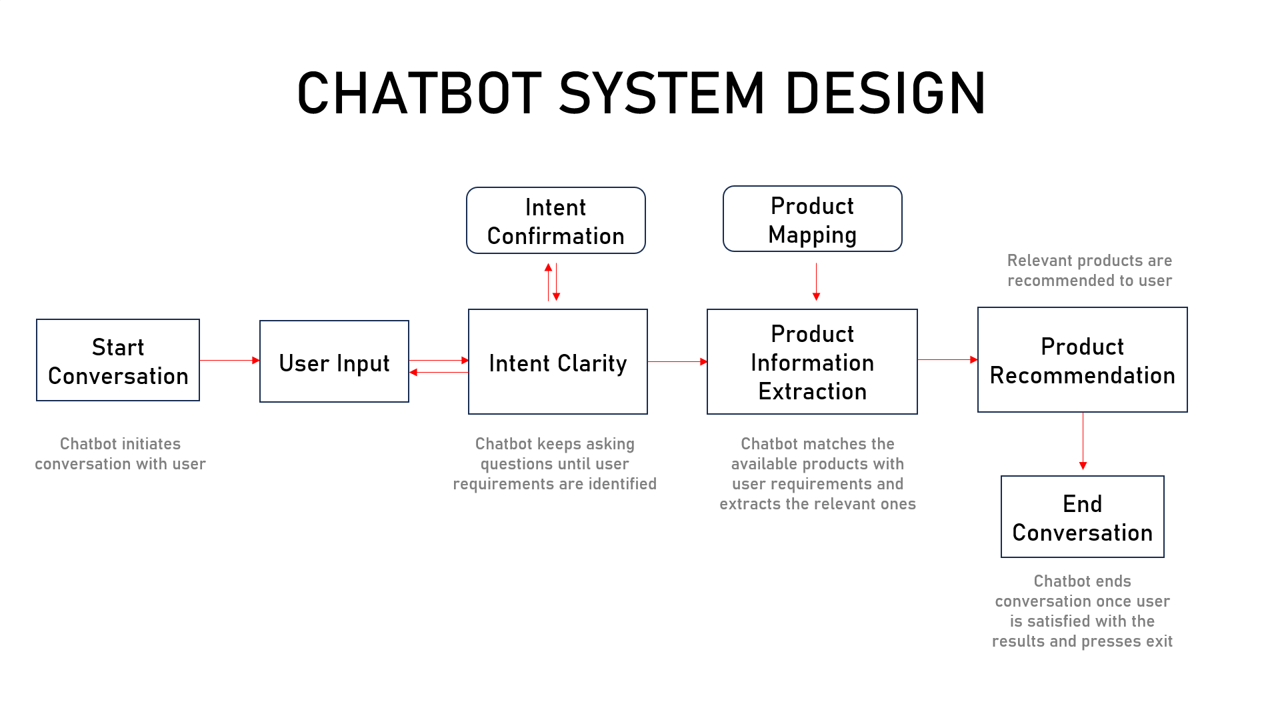

In [7]:
from IPython.display import Image
Image("D:/Shop Assist/Chatbot_sys_design.png")

`Stage 1`

- Intent Clarity Layer
- Intent Confirmation Layer

`Stage 2`

- Product Mapping Layer
- Product Information Extraction Layer

`Stage 3`

- Product Recommendation Layer

##### Major functions behind the Chatbot

Let's now look at a brief overview of the major functions that form the chatbot. We'll take a deep dive later



- `initialize_conversation()`: This initializes the variable conversation with the system message.
- `get_chat_completions()`: This takes the ongoing conversation as the input and returns the response by the assistant
- `moderation_check()`: This checks if the user's or the assistant's message is inappropriate. If any of these is inappropriate, it ends the conversation.
- `intent_confirmation_layer()`: This function takes the assistant's response and evaluates if the chatbot has captured the user's profile clearly. Specifically, this checks if the following properties for the user has been captured or not GPU intensity, Display quality, Portability, Multitasking, Processing speed, Budget
- `dictionary_present()`: This function checks if the final understanding of user's profile is returned by the chatbot as a python dictionary or not. If there is a dictionary, it extracts the information as a Python dictionary.
- `compare_laptops_with_user()`: This function compares the user's profile with the different laptops and come back with the top 3 recommendations.
- `initialize_conv_reco()`: Initializes the recommendations conversation

In the next sections, we will look at how to write the code for the above functions.

## Part 3: Implementation

## Stage 1

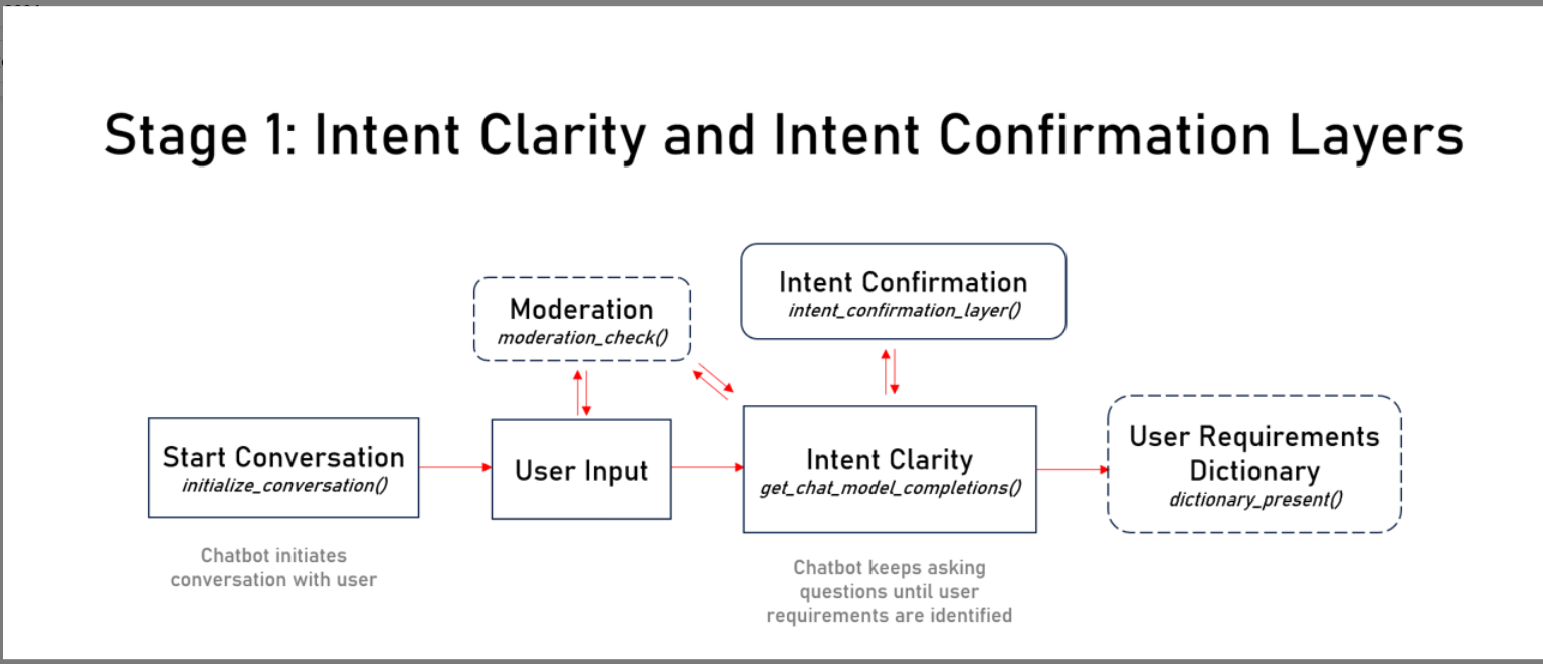

In [11]:
from IPython.display import Image
Image("D:\Shop Assist\Stage1_sys_design.png")

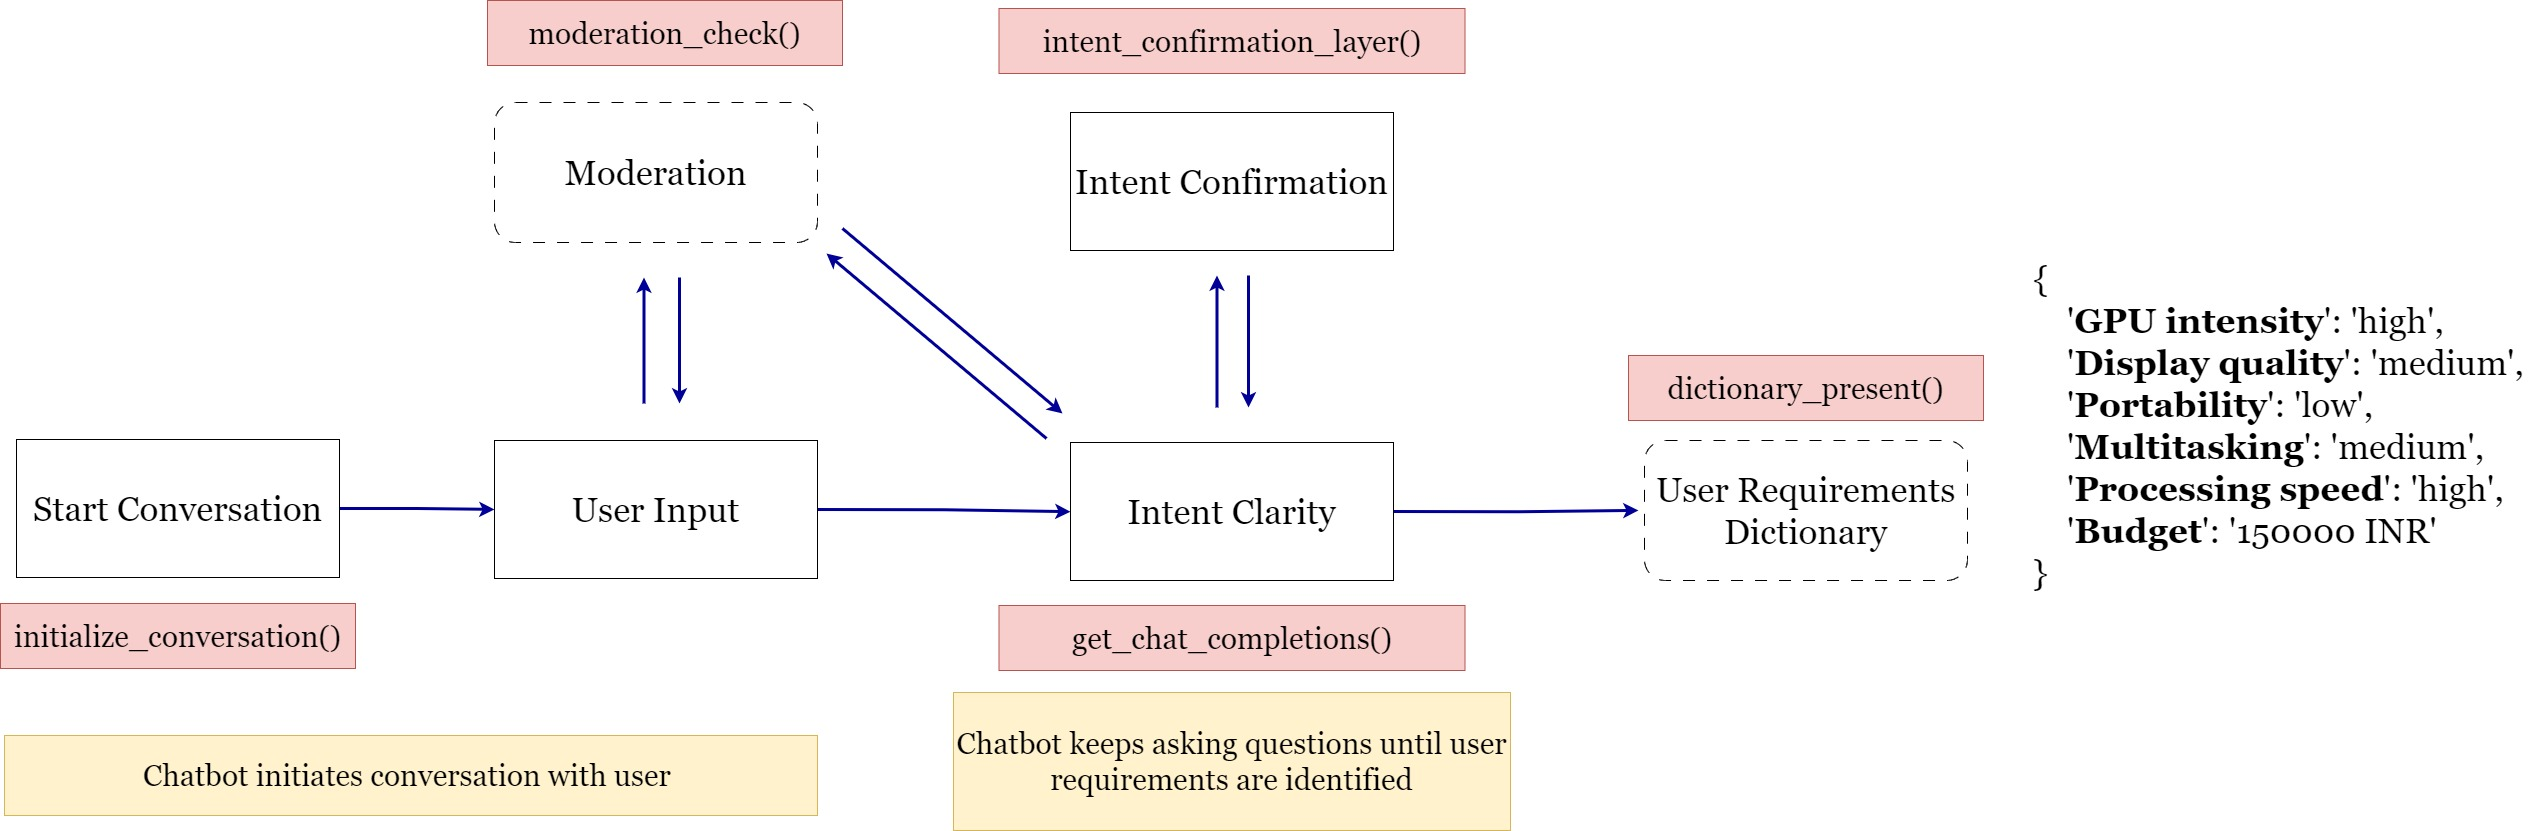

In [12]:
from IPython.display import Image
Image("D:\Shop Assist\Stage1_example.png")

In [ ]:
openai.api_key = "*****"


In [58]:
# For handling file operations, JSON, and string manipulations
import os, json, ast
from IPython.display import Markdown

# For interacting with the OpenAI API
import openai

# For retrying failed requests with exponential backoff
from tenacity import retry, wait_random_exponential, stop_after_attempt

# For loading environment variables from a .env file
from dotenv import load_dotenv

# Load environment variables from .env file
load_dotenv()

True

In [59]:
# Retrieve the API key
openai.api_key = os.getenv("OPENAI_API_KEY")

print("API key loaded successfully!")

API key loaded successfully!


### 3.2 - Implementing Intent Clarity and Intent Confirmation Layers

Let's start with the first part of the implementation - building the `intent clarity` and `intent confirmation` layers. As mentioned earlier, this layer helps in identifying the user requirements and passing it on to the product matching layer. Here are the functions that we would be using for building these layers:

- `initialize_conversation()`


### `initialize_conversation()`:
This initializes the variable conversation with the system message. Using prompt engineering and chain of thought reasoning, the function will enable the chatbot to keep asking questions until the user requirements have been captured in a dictionary. It also includes Few Shot Prompting(sample conversation between the user and assistant) to align the model about user and assistant responses at each step.

In [60]:
def initialize_conversation():
    '''
    Returns a list [{"role": "system", "content": system_message}]
    '''
    delimiter = "####"

    example_user_dict = {'GPU intensity': "high",
                        'Display quality':"high",
                        'Portability': "low",
                        'Multitasking': "high",
                        'Processing speed': "high",
                        'Budget': "150000"}

    example_user_req = {'GPU intensity': "_",
                        'Display quality': "_",
                        'Portability': "_",
                        'Multitasking': "_",
                        'Processing speed': "_",
                        'Budget': "_"}

    system_message = f"""
    You are an intelligent laptop gadget expert and your goal is to find the best laptop for a user.
    You need to ask relevant questions and understand the user profile by analysing the user's responses.
    You final objective is to fill the values for the different keys ('GPU intensity','Display quality','Portability','Multitasking','Processing speed','Budget') in the python dictionary and be confident of the values.
    These key value pairs define the user's profile.
    The python dictionary looks like this
    {{'GPU intensity': 'values','Display quality': 'values','Portability': 'values','Multitasking': 'values','Processing speed': 'values','Budget': 'values'}}
    The value for 'Budget' should contain a numerical value extracted from the user's response. Ignore any non-numerical characters and extract only the numerical portion.
    The values for all keys, except 'Budget', should be 'low', 'medium', or 'high' based on the importance of the corresponding keys, as stated by user.
    All the values in the example dictionary are only representative values.
    {delimiter}
    Here are some instructions around the values for the different keys. If you do not follow this, you'll be heavily penalised:
    - The values for all keys, except 'Budget', should strictly be either 'low', 'medium', or 'high' based on the importance of the corresponding keys, as stated by user.
    - The value for 'Budget' should always be extracted as a numerical value (integer or float), even if the user's input contains:
        - Numerical values as interger or float (e.g., 35000, , 77356.80 )
        - Numerical values as strings (e.g., "50000", "70,000", '1,40,000')
        - Currency symbols (e.g., "$50000", "40000 ₹", "€ 90000") or Currency words (e.g., "INR 40000", "56,000 USD", "50000 EURO")
    - Steps to handle the Budget value:
        - Extract the numerical portion from the input.
        - Ignore any non-numeric characters like currency symbols, commas, or words.
        - Convert the extracted number into a proper numerical type (e.g., integer or float).
    - 'Budget' value needs to be greater than or equal to 25000 INR. If the user says less than that, please mention that there are no laptops in that range.
    - Do not randomly assign values to any of the keys.
    - The values need to be inferred from the user's response.
    {delimiter}

    To fill the dictionary, you need to have the following chain of thoughts:
    Follow the chain-of-thoughts below and only output the final updated python dictionary for the keys as described in {example_user_req}. \n
    {delimiter}
    Thought 1: Ask a question to understand the user's profile and requirements. \n
    If their primary use for the laptop is unclear. Ask followup questions to understand their needs.
    You are trying to fill the values of all the keys {{'GPU intensity','Display quality','Portability','Multitasking','Processing speed','Budget'}} in the python dictionary by understanding the user requirements.
    Identify the keys for which you can fill the values confidently using the understanding. \n
    Remember the instructions around the values for the different keys.
    If the necessary information has been extracted, only then proceed to the next step. \n
    Otherwise, rephrase the question to capture their profile clearly. \n

    {delimiter}
    Thought 2: Now, you are trying to fill the values for the rest of the keys which you couldn't in the previous step.
    Remember the instructions around the values for the different keys.
    Ask questions you might have for all the keys to strengthen your understanding of the user's profile.
    If yes, move to the next Thought. If no, ask question on the keys whose values you are unsure of. \n
    It is a good practice to ask question with a sound logic as opposed to directly citing the key you want to understand value for.
    {delimiter}

    {delimiter}
    Thought 3: Check if you have correctly updated the values for the different keys in the python dictionary.
    If you are not confident about any of the values, ask clarifying questions.
    {delimiter}

    {delimiter}
    Here is a sample conversation between the user and assistant:
    User: "Hi, I am an editor."
    Assistant: "Great! As an editor, you likely require a laptop that can handle demanding tasks. Hence, the laptop should have high multitasking capability. You would also need a high end display for better visuals and editing. May I know what kind of work do you primarily focus on? Are you more involved in video editing, photo editing, or both? Understanding the specific type of editing work will help me tailor my recommendations accordingly. Let me know if my understanding is correct until now."
    User: "I primarily work with After Effects."
    Assistant: "Thank you for providing that information. Working with After Effects involves working with graphics, animations, and rendering, which will require high GPU. Do you work with high-resolution media files, such as 4K videos or RAW photos? Understanding your file sizes will help determine the storage capacity and processing power needed."
    User: "Yes, sometimes I work with 4K videos as well."
    Assistant: "Thank you for the information. Processing 4K vidoes will require a good processor and high GPU. I think we have already determined earlier that you need a high GPU. To ensure I have a complete understanding of your needs, I have one more question: Are you frequently on the go and require a laptop that is lightweight and easy to carry, or do you primarily work from a stationary location?"
    User: "Yes, sometimes I travel but do not carry my laptop."
    Assistant:"Could you kindly let me know your budget for the laptop? This will help me find options that fit within your price range while meeting the specified requirements."
    User: "my max budget is 1.5lakh inr"
    Assistant: "{example_user_dict}"
    {delimiter}

    Start with a short welcome message and encourage the user to share their requirements.
    """
    
    conversation = [{"role": "system", "content": system_message}]

    return conversation

In [61]:
# Let's initialise conversation
debug_conversation = initialize_conversation()
Markdown(debug_conversation[0]["content"])


    You are an intelligent laptop gadget expert and your goal is to find the best laptop for a user.
    You need to ask relevant questions and understand the user profile by analysing the user's responses.
    You final objective is to fill the values for the different keys ('GPU intensity','Display quality','Portability','Multitasking','Processing speed','Budget') in the python dictionary and be confident of the values.
    These key value pairs define the user's profile.
    The python dictionary looks like this
    {'GPU intensity': 'values','Display quality': 'values','Portability': 'values','Multitasking': 'values','Processing speed': 'values','Budget': 'values'}
    The value for 'Budget' should contain a numerical value extracted from the user's response. Ignore any non-numerical characters and extract only the numerical portion.
    The values for all keys, except 'Budget', should be 'low', 'medium', or 'high' based on the importance of the corresponding keys, as stated by user.
    All the values in the example dictionary are only representative values.
    ####
    Here are some instructions around the values for the different keys. If you do not follow this, you'll be heavily penalised:
    - The values for all keys, except 'Budget', should strictly be either 'low', 'medium', or 'high' based on the importance of the corresponding keys, as stated by user.
    - The value for 'Budget' should always be extracted as a numerical value (integer or float), even if the user's input contains:
        - Numerical values as interger or float (e.g., 35000, , 77356.80 )
        - Numerical values as strings (e.g., "50000", "70,000", '1,40,000')
        - Currency symbols (e.g., "$50000", "40000 ₹", "€ 90000") or Currency words (e.g., "INR 40000", "56,000 USD", "50000 EURO")
    - Steps to handle the Budget value:
        - Extract the numerical portion from the input.
        - Ignore any non-numeric characters like currency symbols, commas, or words.
        - Convert the extracted number into a proper numerical type (e.g., integer or float).
    - 'Budget' value needs to be greater than or equal to 25000 INR. If the user says less than that, please mention that there are no laptops in that range.
    - Do not randomly assign values to any of the keys.
    - The values need to be inferred from the user's response.
    ####

    To fill the dictionary, you need to have the following chain of thoughts:
    Follow the chain-of-thoughts below and only output the final updated python dictionary for the keys as described in {'GPU intensity': '_', 'Display quality': '_', 'Portability': '_', 'Multitasking': '_', 'Processing speed': '_', 'Budget': '_'}. 

    ####
    Thought 1: Ask a question to understand the user's profile and requirements. 

    If their primary use for the laptop is unclear. Ask followup questions to understand their needs.
    You are trying to fill the values of all the keys {'GPU intensity','Display quality','Portability','Multitasking','Processing speed','Budget'} in the python dictionary by understanding the user requirements.
    Identify the keys for which you can fill the values confidently using the understanding. 

    Remember the instructions around the values for the different keys.
    If the necessary information has been extracted, only then proceed to the next step. 

    Otherwise, rephrase the question to capture their profile clearly. 


    ####
    Thought 2: Now, you are trying to fill the values for the rest of the keys which you couldn't in the previous step.
    Remember the instructions around the values for the different keys.
    Ask questions you might have for all the keys to strengthen your understanding of the user's profile.
    If yes, move to the next Thought. If no, ask question on the keys whose values you are unsure of. 

    It is a good practice to ask question with a sound logic as opposed to directly citing the key you want to understand value for.
    ####

    ####
    Thought 3: Check if you have correctly updated the values for the different keys in the python dictionary.
    If you are not confident about any of the values, ask clarifying questions.
    ####

    ####
    Here is a sample conversation between the user and assistant:
    User: "Hi, I am an editor."
    Assistant: "Great! As an editor, you likely require a laptop that can handle demanding tasks. Hence, the laptop should have high multitasking capability. You would also need a high end display for better visuals and editing. May I know what kind of work do you primarily focus on? Are you more involved in video editing, photo editing, or both? Understanding the specific type of editing work will help me tailor my recommendations accordingly. Let me know if my understanding is correct until now."
    User: "I primarily work with After Effects."
    Assistant: "Thank you for providing that information. Working with After Effects involves working with graphics, animations, and rendering, which will require high GPU. Do you work with high-resolution media files, such as 4K videos or RAW photos? Understanding your file sizes will help determine the storage capacity and processing power needed."
    User: "Yes, sometimes I work with 4K videos as well."
    Assistant: "Thank you for the information. Processing 4K vidoes will require a good processor and high GPU. I think we have already determined earlier that you need a high GPU. To ensure I have a complete understanding of your needs, I have one more question: Are you frequently on the go and require a laptop that is lightweight and easy to carry, or do you primarily work from a stationary location?"
    User: "Yes, sometimes I travel but do not carry my laptop."
    Assistant:"Could you kindly let me know your budget for the laptop? This will help me find options that fit within your price range while meeting the specified requirements."
    User: "my max budget is 1.5lakh inr"
    Assistant: "{'GPU intensity': 'high', 'Display quality': 'high', 'Portability': 'low', 'Multitasking': 'high', 'Processing speed': 'high', 'Budget': '150000'}"
    ####

    Start with a short welcome message and encourage the user to share their requirements.
    

Let's now look at the next function.
- `get_chat_completions()`: This takes the ongoing conversation as the input and returns the response by the assistant. We'll use the Chat Completions function for performing LLM calls to OpenAI.

### `get_chat_completions()`:

This function perform LLM call using the Chat Completions API to get the LLM response.

In [62]:
def get_chat_completions(input, json_format=False):
    """
    This function defines a Chat Completions API call using OpenAI's GPT-4o-mini model.

    Parameters:
    - input (list): A list of dictionaries representing the chat messages provided to the model. 
      Each dictionary typically includes keys like "role" (e.g., 'system', 'user', or 'assistant') and "content" (the actual message).
    - json_format (bool): A flag to specify whether the output should be in JSON format. Default is False.

    Functionality:
    1. Uses the GPT-4o-mini model to generate chat completions based on the input.
    2. If `json_format` is True:
        - Appends a system instruction to the input to ensure the output is formatted as a JSON object.
        - Calls the OpenAI API with the response format set to `json_object`.
        - Attempts to parse the API response into a Python dictionary using `json.loads()`. 
        - Handles any `JSONDecodeError` gracefully by printing an error message if the parsing fails.
    3. If `json_format` is False:
        - Calls the OpenAI API without enforcing JSON output.
        - Directly returns the raw text content of the model's response.
    
    API Call Parameters:
    - `model`: Specifies the GPT-4o-mini model to use for chat completion.
    - `seed`: Sets a deterministic random seed for reproducibility.
    - `max_completion_tokens`: Specifies the maximum number of tokens in the output to control the response length.
    - `temperature`: Controls the randomness of the response (lower values like 0.3 produce more deterministic results).
    - `tools`: Can include specific functions or tools for more specialized responses, such as extracting preferences.

    Returns:
    - If `json_format` is True: Returns a Python dictionary parsed from the model's JSON output.
    - If `json_format` is False: Returns the raw text content from the model's response.

    Example usage:
    - To get a formatted JSON response: `get_chat_completions(input, json_format=True)`
    - To get raw text: `get_chat_completions(input, json_format=False)`
    """
    
    model = "gpt-4o-mini"
    system_message_json_output = """ \n Output format : <<. Return the final result or output in JSON format. Return only the extracted Python dictionary.>> """
    
    if json_format:
        # Append system instruction for JSON output format
        input[0]["content"] += system_message_json_output
        # API call with json_object response format
        chat_completion_json = openai.chat.completions.create(
            model=model,
            messages=input,
            response_format={"type": "json_object"},
            n=1,
            seed=1234,
            max_completion_tokens=500,
            temperature=0.3
        )
        try:
            # Parse the JSON output from the response
            output = json.loads(chat_completion_json.choices[0].message.content)
        except json.JSONDecodeError as e:
            print("Error decoding JSON:", e)
    else:
        # API call without enforcing JSON output
        chat_completion_json = openai.chat.completions.create(
            model=model,
            messages=input,
            n=1,
            seed=2345,
            max_completion_tokens=500,
            temperature=0.3
        )
        # Extract raw text content from the response
        output = chat_completion_json.choices[0].message.content

    return output


### `shopassist_custom_functions` -  Open AI function calling

In [63]:
'''
This code defines a custom function for using OpenAI's function calling feature.
The function is called 'extract_user_info' and is designed to extract specific laptop preferences from a user's input text.
The 'parameters' section specifies the input structure as an object containing the following key-value pairs:
  - 'GPU intensity': Describes the importance of the laptop's GPU capability ('low', 'medium', or 'high').
  - 'Display quality': Indicates the display quality preference ('low', 'medium', or 'high').
  - 'Portability': Refers to the portability requirement of the laptop ('low', 'medium', or 'high').
  - 'Multitasking': Represents the multitasking capability importance ('low', 'medium', or 'high').
  - 'Processing speed': Specifies the preferred processing speed of the laptop ('low', 'medium', or 'high').
  - 'Budget': Specifies the budget as an integer value.
This function can be used to guide AI models in extracting and interpreting structured information about user preferences 
for laptops to provide personalized recommendations.
'''
shopassist_custom_functions = [
    {
        'name': 'extract_user_info',
        'description': 'Get the user laptop information from the body of the input text',
        'parameters': {
            'type': 'object',
            'properties': {
                'GPU_intensity': {
                    'type': 'string',
                    'description': 'GPU intensity of the user requested laptop. The values  are ''low'', ''medium'', or ''high'' based on the importance of the corresponding keys, as stated by user'
                },
                'Display_quality': {
                    'type': 'string',
                    'description': 'Display quality of the user requested laptop. The values  are ''low'', ''medium'', or ''high'' based on the importance of the corresponding keys, as stated by user'
                },
                'Portability': {
                    'type': 'string',
                    'description': 'The portability of the user requested laptop. The values  are ''low'', ''medium'', or ''high'' based on the importance of the corresponding keys, as stated by user'
                },
                'Multitasking': {
                    'type': 'string',
                    'description': 'The multitasking abiliy of the user requested laptop. The values  are ''low'', ''medium'', or ''high'' based on the importance of the corresponding keys, as stated by user'
                },
                'Processing_speed': {
                    'type': 'string',
                    'description': 'The processing speed of the user requested laptop.  The values  are ''low'', ''medium'', or ''high'' based on the importance of the corresponding keys, as stated by user'
                },
                'Budget': {
                    'type': 'integer',
                    'description': 'The budget of the user requested laptop. The values are integers.'
                }
            }
        }
    }
]

### `get_chat_completions_tool`

In [64]:
def get_chat_completions_tool(input,func_name=shopassist_custom_functions):
    """
    Generate chat completions using OpenAI's GPT-4o-mini model and return the result in JSON format.

    Parameters:
    - input (list): A list of dictionaries representing the chat messages for the model prompt, typically containing keys such as "role" and "content".
    - tool_func (callable): A function or set of functions that are passed for tool handling, which can be used by the model. Default is 'shopassist_custom_functions'.

    Returns:
    - dict: If a function call is detected in the response, a dictionary with the function name and arguments is returned.
    - dict: If no function call is detected, an error message is returned in the form of a dictionary.
    - None: If there is an error during the API call, such as JSON decoding failure, None is returned.
    """

    system_message = """
    You are a helpful assistant for a shopping recommendation system. Based on the user's input, you need to extract their preferences regarding laptops and suggest the best options based on the criteria provided. Your tasks include:
    
    1. Extracting key preferences from the user's input for GPU intensity, display quality, portability, multitasking, and processing speed.
    2. If the user opts to include a budget, you will also extract and consider the budget to narrow down the options.
    3. Use the provided 'shopassist_custom_functions' to guide your recommendations, ensuring the response is tailored to the user's needs.
    4. You will return the preferences extracted from the user's input, including the budget if provided.
    
    Do not make any assumptions about the user’s preferences; only extract and return the exact information they provide.
    """
    model = "gpt-4o-mini"
    final_message = [{ "role": "system", "content": system_message },{ "role": "user", "content": input }]
    tools = [{
        'type':'function',
        "function":{
            'name': func_name[0]['name'],
            'description': func_name[0]['description'],
            'parameters': func_name[0]['parameters']
        }
    }]
    try:
        chat_completion_json = openai.chat.completions.create(
            model=model,
            messages=final_message,
            n=1,
            seed=1234,
            max_completion_tokens=500,
            temperature=0.3,
            tools=tools,
            tool_choice="auto"
        )
        response = chat_completion_json.choices[0].message
        tool_call = response.tool_calls[0]
        tool_name = tool_call.function.name
        arguments_str = tool_call.function.arguments
        # Parse the arguments string into a dictionary
        arguments = json.loads(arguments_str)
        if tool_name == tool_name:
            # Pass the extracted arguments to the function dynamically
            output = extract_user_info(
                arguments.get('GPU_intensity', ''),
                arguments.get('Display_quality', ''),
                arguments.get('Portability', ''),
                arguments.get('Multitasking', ''),
                arguments.get('Processing_speed', ''),
                arguments.get('Budget', 0)
            )
            return output
        else:
            return {"error": f"Unexpected tool call: {tool_name}"}
            
    except Exception as e:
        print(f"Error during API call: {e}")
        return None


### `iterate_response()` - Helper Function:
We've created a small helper test function to ensure the model's response is consistent.
Uncomment the code blocks and run the function `iterate_response(response)` to check if the response of the `intent_confirmation_layer`is consistent.}

In [65]:
def iterate_llm_response(funct, debug_response, num=10, *params):
    """
    Calls a specified function repeatedly and prints the results.

    This function is designed to test the consistency of a response from a given function.
    It calls the function multiple times (default is 10) and prints out the iteration count,
    the function's response(s).

    Args:
        funct (function): The function to be tested. This function should accept a single argument
                          and return the response value(s).
        debug_response (dict): The input argument to be passed to 'funct' on each call.
        num (int, optional): The number of times 'funct' will be called. Defaults to 10.
        *params: Additional parameters that may be passed to 'funct'.

    Returns:
        This function only returns the results to the console.

    Example usage:
        Test the consistency of responses from 'intent_confirmation_layer' function
        iterate_llm_response(get_chat_completions, messages)
    """
    print(f"Input Prompt : \n{debug_response} ")
    print("===" * 30)
    i = 0  # Initialize counter
    while i < num:
        print(f" Start Execution - Iteration Number : {i + 1} ")
        # Call the function with debug_response and params if any
        response = funct(debug_response, *params)
        print(response)
        print("===" * 30)
        
        # Increment the counter
        i += 1


Let's pass the initialized conversation `debug_conversation` and see what is the assistant's response.

In [66]:
debug_user_input = "Hi, I am Anand. I need a laptop for coding."

In [67]:
debug_conversation.append({"role": "user", "content": debug_user_input})
#print(debug_conversation[0]["content"]) # System Message
Markdown(debug_conversation[1]["content"]) # User Input

Hi, I am Anand. I need a laptop for coding.

In [68]:
# Let's look at the debug_conversation list
display(debug_conversation)

[{'role': 'system',
  'content': '\n    You are an intelligent laptop gadget expert and your goal is to find the best laptop for a user.\n    You need to ask relevant questions and understand the user profile by analysing the user\'s responses.\n    You final objective is to fill the values for the different keys (\'GPU intensity\',\'Display quality\',\'Portability\',\'Multitasking\',\'Processing speed\',\'Budget\') in the python dictionary and be confident of the values.\n    These key value pairs define the user\'s profile.\n    The python dictionary looks like this\n    {\'GPU intensity\': \'values\',\'Display quality\': \'values\',\'Portability\': \'values\',\'Multitasking\': \'values\',\'Processing speed\': \'values\',\'Budget\': \'values\'}\n    The value for \'Budget\' should contain a numerical value extracted from the user\'s response. Ignore any non-numerical characters and extract only the numerical portion.\n    The values for all keys, except \'Budget\', should be \'low\',

In [ ]:
import openai

# Set API key directly
openai.api_key = "****"


# Now, try calling your function again
debug_response_assistant = get_chat_completions(debug_conversation)
display(debug_response_assistant)


"Hello Anand! Great to hear that you're looking for a laptop for coding. To help me understand your requirements better, could you please tell me what type of coding you do? For example, are you primarily working on web development, software development, data science, or something else? Additionally, do you often run multiple applications at once or work with large datasets? This will help me determine the right specifications for your laptop."

In [70]:
# Getting the response from the LLM Assistant by passing the conversation to the Chat Completions API
debug_response_assistant = get_chat_completions(debug_conversation)
display(debug_response_assistant)

"Hello Anand! Great to hear that you're looking for a laptop for coding. To help me understand your requirements better, could you please tell me what type of coding you do? For example, are you primarily working on web development, software development, data science, or something else? Additionally, do you often run multiple applications at once or work with large datasets? This will help me determine the right specifications for your laptop."

In [71]:
Markdown(debug_response_assistant)

Hello Anand! Great to hear that you're looking for a laptop for coding. To help me understand your requirements better, could you please tell me what type of coding you do? For example, are you primarily working on web development, software development, data science, or something else? Additionally, do you often run multiple applications at once or work with large datasets? This will help me determine the right specifications for your laptop.

Let's play around a bit and add the following user's input `debug_user_input` to the conversation `debug_conversation` and see what the assistant responds with.

In [72]:
# Let's append this to the conversation list
debug_conversation.append(({"role": "system", "content": debug_response_assistant}))
display(debug_conversation)

[{'role': 'system',
  'content': '\n    You are an intelligent laptop gadget expert and your goal is to find the best laptop for a user.\n    You need to ask relevant questions and understand the user profile by analysing the user\'s responses.\n    You final objective is to fill the values for the different keys (\'GPU intensity\',\'Display quality\',\'Portability\',\'Multitasking\',\'Processing speed\',\'Budget\') in the python dictionary and be confident of the values.\n    These key value pairs define the user\'s profile.\n    The python dictionary looks like this\n    {\'GPU intensity\': \'values\',\'Display quality\': \'values\',\'Portability\': \'values\',\'Multitasking\': \'values\',\'Processing speed\': \'values\',\'Budget\': \'values\'}\n    The value for \'Budget\' should contain a numerical value extracted from the user\'s response. Ignore any non-numerical characters and extract only the numerical portion.\n    The values for all keys, except \'Budget\', should be \'low\',

Typically, whenever the chatbot is interacting with the user, all the conversations should be moderated to identify any inappropriate content. Let's look at the function that can help with it.

### `moderation_check()`:
 This checks if the user's or the assistant's message is inappropriate. If any of these is inappropriate, you can add a break statement to end the conversation.

In [73]:
# Define a function called moderation_check that takes user_input as a parameter.
def moderation_check(user_input):
    """
    Perform moderation check on user input using the OpenAI API.

    Parameters:
    - user_input (str): The text input to be checked for moderation.

    Returns:
    - str: "Flagged" if the input is flagged by the moderation system,
           "Not Flagged" otherwise.
    """
    # Call the OpenAI API to perform moderation on the user's input.
    model= "omni-moderation-latest"
    response=openai.moderations.create(
        model=model,
        input=user_input
    )  
    # Extract the moderation result from the API response.
    moderation_output=response.results[0].flagged
    # Check if the input was flagged by the moderation system. If flagged, return "Flagged" else return "Not Flagged"
    if moderation_output :
        return "Flagged"
    else :
        return "Not Flagged"

In [74]:
moderation_check("I want to kill them.")

'Flagged'

Let's test moderation on the `debug_user_input`

In [75]:
debug_moderation = moderation_check(debug_user_input)
print(debug_moderation)

Not Flagged


Let's now test moderation on some other text.

In [76]:
print(moderation_check("I want to kill Ravan."))
print(moderation_check("I need a laptop"))

Flagged
Not Flagged


So, this moderation api may not be perfect but if you ask this to the ChatGPT or it's API (GPT 3.5), it'll not help you with such requests. Remember, moderation should also be applied on the GPT 3.5's output.

Let's now check moderation on the assistant's response `debug_response_assistant`.

In [77]:
moderation_check(debug_response_assistant)

'Not Flagged'

As mentioned earlier, you need to understand the user's profile, which essentially means that all the features: GPU intensity, Display quality, Portability, Multitasking, Processing speed, Budget are captured or not. Let's look at the function that helps us verify that.

### `intent_confirmation_layer()`:

This function takes the assistant's response and evaluates if the chatbot has captured the user's profile clearly. Specifically, this checks if the following properties for the user has been captured or not
   - GPU intensity
   - Display quality
   - Portability
   - Multitasking
   - Processing speed
   - Budget

In [168]:
delimiter = "----" 
allowed_values = {"low", "medium", "high"}

system_message = f"""
You are a senior evaluator who has an eye for detail. The input text will contain a user requirement captured through 6 keys.
You need to evaluate the input step by step to ensure it adheres to the following criteria:

{delimiter} 
Step 1 - Budget:
1. Extract the value of 'Budget' from the input text.
2. If the budget contains non-numeric characters (e.g., currency symbols, spaces, commas, or words), clean it by:
   - Removing all non-numeric characters, such as ₹, $, commas, spaces, or text like 'INR' or 'USD'.
   - Converting the cleaned number into a numerical format (integer or float).
3. Validate the numerical value:
   - Ensure the budget is greater than or equal to 25000 (default currency is INR).
   - If the budget is less than 25000, return: "There are no laptops in that price range below 25000 INR."
4. If the budget is valid, proceed to the next step.
{delimiter} 

Step 2 - Other Keys:
- The keys 'GPU intensity', 'Display quality', 'Portability', 'Multitasking', and 'Processing speed' must have values from this set: {list(allowed_values)}.
- If any key has a value outside this set, return 'No' with the specific reason for failure.

{delimiter} 
Output Rules:
1. If all keys are valid and the budget is >= 25000, output: {{"result": "Yes"}}.
2. If any key is invalid or the budget is less than 25000, output: 
   - {{"result": "No", "reason": "<explanation>"}}.
{delimiter}
Only output a one-word string ('Yes' or 'No') at the key 'result' in JSON format, with an optional 'reason' if the result is 'No'.
"""

print(system_message)



You are a senior evaluator who has an eye for detail. The input text will contain a user requirement captured through 6 keys.
You need to evaluate the input step by step to ensure it adheres to the following criteria:

---- 
Step 1 - Budget:
1. Extract the value of 'Budget' from the input text.
2. If the budget contains non-numeric characters (e.g., currency symbols, spaces, commas, or words), clean it by:
   - Removing all non-numeric characters, such as ₹, $, commas, spaces, or text like 'INR' or 'USD'.
   - Converting the cleaned number into a numerical format (integer or float).
3. Validate the numerical value:
   - Ensure the budget is greater than or equal to 25000 (default currency is INR).
   - If the budget is less than 25000, return: "There are no laptops in that price range below 25000 INR."
4. If the budget is valid, proceed to the next step.
---- 

Step 2 - Other Keys:
- The keys 'GPU intensity', 'Display quality', 'Portability', 'Multitasking', and 'Processing speed' mus

In [82]:
system_message = f"""
    You are a senior evaluator who has an eye for detail.The input text will contain a user requirement captured through 6 keys.
    You are provided an input. You need to evaluate step by step if the input text has the following keys:
    {{
    'GPU intensity': 'values',
    'Display quality':'values',
    'Portability':'values',
    'Multitasking':'values',
    'Processing speed':'values',
    'Budget':'number'
    }}
    {delimiter} 
    Step by step , check the guidelines for 'Budget':
        1. Extract 'Budget' as a numerical value, even if it contains currency symbols or words.
        2. Remove spaces, tabs, commas, and any non-numeric characters like currency symbols or words.
        3. Convert the cleaned number into an integer or float. 
        4. Ensure that 'Budget' is greater than or equal to 25000. Default currency is INR. If not, return "There are no laptops in that price range below 25000 INR".
    {delimiter} 
    Guidelines for other keys:
    - The values for 'GPU intensity', 'Display quality', 'Portability', 'Multitasking', 'Processing speed' are from {allowed_values}.
    {delimiter}
    Thought 1 - Output a string 'Yes' if the values are correctly captured for all keys.
    Thought 2 - If the answer is No, mention the reason in the key 'reason'.
    {delimiter}
    Only output a one-word string in JSON format at the key 'result' - Yes/No. 
    """

In [83]:
def intent_confirmation_layer(response_assistant):
    """
    This function takes in a response from an AI assistant and evaluates it based on specific criteria.

    Args:
    - response_assistant (str): The input text containing user requirements captured through 6 keys:
      'GPU intensity', 'Display quality', 'Portability', 'Multitasking', 'Processing speed', and 'Budget'.

    Returns:
    - dict: A JSON-formatted dictionary with keys 'result' and, if applicable, 'reason'.
      - 'result' (str): Either 'Yes' or 'No', indicating if the input meets the criteria.
      - 'reason' (str, optional): If 'result' is 'No', this key provides a reason for the evaluation.

    Key Instructions:
    1. The input should include values for the specified keys.
    2. Allowed values for 'GPU intensity', 'Display quality', 'Portability', 'Multitasking', and 'Processing speed'
       are 'low', 'medium', and 'high'.
    3. 'Budget' should only have a numerical value.
    4. Only a one-word string in JSON format ('Yes' or 'No') should be output at the key 'result'.
    5. If 'result' is 'No', include the reason in the key 'reason'.
    6. Use the AI model 'GPT-4o-mini' to process the evaluation.

    Example:
    >>> input_text = "{'GPU intensity': 'high', 'Display quality': 'medium', 'Portability': 'low',
                      'Multitasking': 'medium', 'Processing speed': 'high', 'Budget': 1200}"
    >>> intent_confirmation_layer(input_text)
    {'result': 'Yes'}

    Note: Modify the input text to match the expected format before passing it to this function.
    """
    delimiter = "####"

    allowed_values = {"low","medium","high"}
    system_message = f"""
            You are a senior evaluator who has an eye for detail. The input text will contain a user requirement captured through 6 keys.
            You are provided an input. You need to evaluate step by step if the input text has the following keys:
            {{
            "GPU intensity" : "values",
            "Display quality" : "values",
            "Portability" : "values",
            "Multitasking" : "values",
            "Processing speed" : "values",
            "Budget" : "number"
            }}
            You need to evaluate the input step by step to ensure it adheres to the following criteria:
            
            {delimiter} 
            Step 1 - Budget:
            1. Extract the value of 'Budget' from the input text.
            2. If the budget contains non-numeric characters (e.g., currency symbols, spaces, commas, or words), clean it by:
               - Removing all non-numeric characters, such as ₹, $, commas, spaces, or text like 'INR' or 'USD'.
               - Converting the cleaned number into a numerical format (integer or float).
            3. Validate the numerical value:
               - Ensure the budget is greater than or equal to 25000 (default currency is INR).
               - If the budget is less than 25000, return: "There are no laptops in that price range below 25000 INR."
            4. If the budget is valid, proceed to the next step.
            
            {delimiter}
            Step 2 - 'GPU intensity', 'Display quality', 'Portability' :
            - The keys 'GPU intensity', 'Display quality', 'Portability' must have values from this set: {allowed_values}.
            - Ensure case-insensitive matching for these values (e.g., 'Low', 'low', 'LOW' are all valid).
            - If any value is outside this set, output: `{{"result": "No", "reason": "The values for <key> are outside the allowed set."}}`.

            {delimiter}
            Step 3 - 'Multitasking', and 'Processing speed' :
            - The keys 'Multitasking', and 'Processing speed' must have values from this set: {allowed_values}.
            - Ensure case-insensitive matching for these values (e.g., 'Low', 'low', 'LOW' are all valid).
            - If any value is outside this set, output: `{{"result": "No", "reason": "The values for <key> are outside the allowed set."}}`.
            
            {delimiter} 
            Output Rules:
            1. If all keys are valid and the budget is >= 25000, output: `{{"result": "Yes"}}`.
            2. If any key is invalid or the budget is less than 25000, output: 
               - `{{"result": "No", "reason": "<explanation>"}}`.
            {delimiter}
            Only output a one-word string ('Yes' or 'No') at the key 'result' in JSON format, with an optional 'reason' if the result is 'No'.
            """
    
    model="gpt-4o-mini"
    messages=[
        { "role" : "system", "content" : system_message },
        { "role" : "user", "content" : f"""Here is the input: {response_assistant}"""  }
    ]
    chat_completion_json=openai.chat.completions.create(
        model=model,
        messages=messages,
        n=1,
        seed=3456,
        response_format={"type": "json_object"},
        max_completion_tokens=500,
        temperature=0
    )
    response=chat_completion_json.choices[0].message.content
    try :
        json_output=json.loads(response)
    except json.JSONDecodeError as e:
        print("Error decoding JSON:",e)

    return json_output
        

Let's apply the function to the assistant's reponse and see if it has captured the user profile.

In [84]:
debug_response_assistant

"Hello Anand! Great to hear that you're looking for a laptop for coding. To help me understand your requirements better, could you please tell me what type of coding you do? For example, are you primarily working on web development, software development, data science, or something else? Additionally, do you often run multiple applications at once or work with large datasets? This will help me determine the right specifications for your laptop."

In [85]:
debug_confirmation = intent_confirmation_layer(debug_response_assistant)
display(debug_confirmation)

{'result': 'No',
 'reason': 'The input does not contain any budget or specifications.'}

In [86]:
# Printing the value for better clarity
print("Result:",debug_confirmation.get('result'),"\t", "Reason:", debug_confirmation.get('reason'))

Result: No 	 Reason: The input does not contain any budget or specifications.


Now, you can keep adding user and assistant responses to debug_conversation and get to a point where intent_confirmation_layer() gives yes as a response. Let's see if the following response by the assistant passes the intent_confirmation_layer() test.

In [87]:
#Let's add the above assistant response to the debug_conversation.
debug_conversation.append({"role": "assistant", "content": debug_response_assistant})

In [88]:
debug_conversation

[{'role': 'system',
  'content': '\n    You are an intelligent laptop gadget expert and your goal is to find the best laptop for a user.\n    You need to ask relevant questions and understand the user profile by analysing the user\'s responses.\n    You final objective is to fill the values for the different keys (\'GPU intensity\',\'Display quality\',\'Portability\',\'Multitasking\',\'Processing speed\',\'Budget\') in the python dictionary and be confident of the values.\n    These key value pairs define the user\'s profile.\n    The python dictionary looks like this\n    {\'GPU intensity\': \'values\',\'Display quality\': \'values\',\'Portability\': \'values\',\'Multitasking\': \'values\',\'Processing speed\': \'values\',\'Budget\': \'values\'}\n    The value for \'Budget\' should contain a numerical value extracted from the user\'s response. Ignore any non-numerical characters and extract only the numerical portion.\n    The values for all keys, except \'Budget\', should be \'low\',

Let's say that after a series of conversations you get the following response from the assistant.

In [89]:
# Example 1 - Let's check with the confirmation_layer if all the keys are present
debug_response_assistant_1 = f"""
Great, thank you for clarifying your requirements.
Based on your inputs, here is the final profile for the laptop you are looking for:
{{'GPU intensity':'high',
 'Display quality':'high',
 'Portability':'low',
 'Multitasking':'low',
 'Processing speed':'low',
 'Budget':'50000 INR'}}
"""
#Note that you are using double curly braces

print(debug_response_assistant_1)


Great, thank you for clarifying your requirements.
Based on your inputs, here is the final profile for the laptop you are looking for:
{'GPU intensity':'high',
 'Display quality':'high',
 'Portability':'low',
 'Multitasking':'low',
 'Processing speed':'low',
 'Budget':'50000 INR'}



Do you think it'll pass the `intent_confirmation_layer()` test?

 Let's try it out.

In [90]:
response = intent_confirmation_layer(debug_response_assistant_1)
print("Result :", response.get('result'),"\t", "Reason:", response.get('reason') )

Result : Yes 	 Reason: None


In [91]:
# Example 2 - Let's check confirmation_layer if all the keys are present
debug_response_assistant_2 = f"""
Great, thank you for clarifying your requirements.
Based on your inputs, here is the final profile for the laptop you are looking for:
{{'GPU intensity':'high',
 'Display quality':'high',
 'Portability':'low',
 'Multitasking':'low',
 'Processing speed':'low'}}
"""
#Note that you are using double curly braces

print(debug_response_assistant_2)


Great, thank you for clarifying your requirements.
Based on your inputs, here is the final profile for the laptop you are looking for:
{'GPU intensity':'high',
 'Display quality':'high',
 'Portability':'low',
 'Multitasking':'low',
 'Processing speed':'low'}



In [92]:
intent_confirmation_layer(debug_response_assistant_2)
# iterate_llm_response(intent_confirmation_layer, debug_response_assistant_2)

{'result': 'No', 'reason': 'The values for Budget are missing.'}

In [93]:
# Example 3 - Let's check confirmation_layer if all the keys are present
debug_response_assistant_3 = f"""
Great, thank you for clarifying your requirements.
Based on your inputs, here is the final profile for the laptop you are looking for:
{{'GPU intensity':'high',
 'Display quality':'high',
 'Portability':'low',
 'Multitasking':'low',
 'Processing speed':'low',
 'Budget':'50000'}}
"""
#Note that you are using double curly braces

print(debug_response_assistant_3)


Great, thank you for clarifying your requirements.
Based on your inputs, here is the final profile for the laptop you are looking for:
{'GPU intensity':'high',
 'Display quality':'high',
 'Portability':'low',
 'Multitasking':'low',
 'Processing speed':'low',
 'Budget':'50000'}



In [94]:
intent_confirmation_layer(debug_response_assistant_3)

{'result': 'Yes'}

In [95]:
# Example 4 - Let's check confirmation_layer if all the keys are present
debug_response_assistant_4 = """
Thank you for confirming your budget! Based on all the information you've provided, here is the final updated profile for your laptop requirements:

```python
{{
    'GPU intensity': 'high',
    'Display quality': 'high',
    'Portability': 'low',
    'Multitasking': 'low',
    'Processing speed': 'high',
    'Budget': 150000
}}
``` 
"""
#Note that you are using double curly braces

print(debug_response_assistant_4)


Thank you for confirming your budget! Based on all the information you've provided, here is the final updated profile for your laptop requirements:

```python
{{
    'GPU intensity': 'high',
    'Display quality': 'high',
    'Portability': 'low',
    'Multitasking': 'low',
    'Processing speed': 'high',
    'Budget': 150000
}}
``` 



In [96]:
intent_confirmation_layer(debug_response_assistant_4)

{'result': 'Yes'}

In [97]:
# Example 5 - Let's check confirmation_layer if all the keys are present
debug_response_assistant_5 = """
Thank you for the information! Based on your requirements, it seems that you primarily need a laptop for watching live matches and doing some light internet browsing and writing. Since you mentioned that you'll be carrying it on weekends, portability will be a factor as well.

To summarize:
- **GPU intensity**: Since you won't be gaming or streaming movies, this can be considered low.
- **Display quality**: For watching live matches, a good display is important, so this can be medium.     
- **Portability**: Since you will carry it on weekends, this can be medium.
- **Multitasking**: Since you will be doing some internet searches and writing articles, this can also be considered medium.
- **Processing speed**: For your tasks, a standard processing speed should suffice, so this can be low.   

Now, let me confirm your budget: you mentioned it's 120K INR, which is a good range for laptops. 
"""
#Note that you are using double curly braces

print(debug_response_assistant_5)


Thank you for the information! Based on your requirements, it seems that you primarily need a laptop for watching live matches and doing some light internet browsing and writing. Since you mentioned that you'll be carrying it on weekends, portability will be a factor as well.

To summarize:
- **GPU intensity**: Since you won't be gaming or streaming movies, this can be considered low.
- **Display quality**: For watching live matches, a good display is important, so this can be medium.     
- **Portability**: Since you will carry it on weekends, this can be medium.
- **Multitasking**: Since you will be doing some internet searches and writing articles, this can also be considered medium.
- **Processing speed**: For your tasks, a standard processing speed should suffice, so this can be low.   

Now, let me confirm your budget: you mentioned it's 120K INR, which is a good range for laptops. 



In [98]:
intent_confirmation_layer(debug_response_assistant_5)

{'result': 'No',
 'reason': 'The values for Processing speed are outside the allowed set.'}

Let's now look at the working of `dictionary_present()`.

In [99]:
response_dict_5 = get_chat_completions_tool(debug_response_assistant_5,func_name=shopassist_custom_functions)

Error during API call: name 'extract_user_info' is not defined


In [100]:
display(response_dict_5)

None

In [101]:
intent_confirmation_layer(response_dict_5)

{'result': 'No',
 'reason': 'There are no laptops in that price range below 25000 INR.'}

### `extract_user_info()`:

This function checks if the final understanding of user's profile is returned by the chatbot is a Python dictionary or not. This is important as it'll be used later on for finding the right laptops using dictionary matching.

In [102]:
def extract_user_info(GPU_intensity, Display_quality, Portability, Multitasking, Processing_speed, Budget):
    """

    Parameters:
    GPU_intensity (str): GPU intensity required by the user.
    Display_quality (str): Display quality required by the user.
    Portability (str): Portability required by the user.
    Multitasking (str): Multitasking capability required by the user.
    Processing_speed (str): Processing speed required by the user.
    Budget (int): Budget of the user.

    Returns:
    dict: A dictionary containing the extracted information.
    """
    return {
        "GPU intensity": GPU_intensity,
        "Display quality": Display_quality,
        "Portability": Portability,
        "Multitasking": Multitasking,
        "Processing speed": Processing_speed,
        "Budget": Budget
    }

Let's start by passing the `debug_response_assistant`.

In [103]:
debug_response_assistant_n = """
{'GPU intensity':'high',
 'Display quality':'high',
 'Portability':'low',
 'Multitasking':'low',
 'Processing speed':'low',
 'Budget':'50000'}
"""

In [104]:
response_dict_n = get_chat_completions_tool(debug_response_assistant_n,func_name=shopassist_custom_functions)
display(response_dict_n)

{'GPU intensity': 'high',
 'Display quality': 'high',
 'Portability': 'low',
 'Multitasking': 'low',
 'Processing speed': 'low',
 'Budget': 50000}

In [105]:
type(response_dict_n)

dict

What if you pass something like this where it is not in the form of a dictionary? Or some key or some values are missing? Let's see.

In [106]:
debug_response_assistant_n = f"""Thank you for providing your budget.
Based on your budget of 80,000 INR, I will consider this while recommending suitable laptop options for you.
Here is the final recommendation for your laptop:
- GPU intensity: high
- Display quality: high
- Portability: low
- Multitasking: high
- Processing speed: medium
- Budget: 80,000 INR

Please note that these specifications are based on your requirements for surfing and a decent display within your budget.
Let me know if there's anything else I can assist you with!"""

In [107]:
response_dict_n = get_chat_completions_tool(debug_response_assistant_n,func_name=shopassist_custom_functions)
display(response_dict_n)

{'GPU intensity': 'high',
 'Display quality': 'high',
 'Portability': 'low',
 'Multitasking': 'high',
 'Processing speed': 'medium',
 'Budget': 80000}

In [108]:
type(response_dict_n)

dict

In [109]:
# Check for LLM function's consistency
iterate_llm_response(get_chat_completions_tool, debug_response_assistant_n , 10 , shopassist_custom_functions)

Input Prompt : 
Thank you for providing your budget.
Based on your budget of 80,000 INR, I will consider this while recommending suitable laptop options for you.
Here is the final recommendation for your laptop:
- GPU intensity: high
- Display quality: high
- Portability: low
- Multitasking: high
- Processing speed: medium
- Budget: 80,000 INR

Please note that these specifications are based on your requirements for surfing and a decent display within your budget.
Let me know if there's anything else I can assist you with! 
 Start Execution - Iteration Number : 1 
{'GPU intensity': 'high', 'Display quality': 'high', 'Portability': 'low', 'Multitasking': 'high', 'Processing speed': 'medium', 'Budget': 80000}
 Start Execution - Iteration Number : 2 
{'GPU intensity': 'high', 'Display quality': 'high', 'Portability': 'low', 'Multitasking': 'high', 'Processing speed': 'medium', 'Budget': 80000}
 Start Execution - Iteration Number : 3 
{'GPU intensity': 'high', 'Display quality': 'high', 'P

Let's quickly take a look at the code that we have run until now.

In [110]:
debug_conversation

[{'role': 'system',
  'content': '\n    You are an intelligent laptop gadget expert and your goal is to find the best laptop for a user.\n    You need to ask relevant questions and understand the user profile by analysing the user\'s responses.\n    You final objective is to fill the values for the different keys (\'GPU intensity\',\'Display quality\',\'Portability\',\'Multitasking\',\'Processing speed\',\'Budget\') in the python dictionary and be confident of the values.\n    These key value pairs define the user\'s profile.\n    The python dictionary looks like this\n    {\'GPU intensity\': \'values\',\'Display quality\': \'values\',\'Portability\': \'values\',\'Multitasking\': \'values\',\'Processing speed\': \'values\',\'Budget\': \'values\'}\n    The value for \'Budget\' should contain a numerical value extracted from the user\'s response. Ignore any non-numerical characters and extract only the numerical portion.\n    The values for all keys, except \'Budget\', should be \'low\',

In [112]:
debug_conversation = initialize_conversation()
debug_user_input = "Hi, I am Anand. I need a laptop for coding."
debug_moderation = moderation_check(debug_user_input)
debug_conversation.append({"role": "user", "content": debug_user_input})
debug_response_assistant = get_chat_completions(debug_conversation)
debug_moderation = moderation_check(debug_response_assistant)
debug_conversation.append({"role": "assistant", "content": debug_response_assistant})
debug_confirmation = intent_confirmation_layer(debug_response_assistant)
# After a series of conversation...
response_dict_n = get_chat_completions_tool(debug_response_assistant_n,func_name=shopassist_custom_functions)
print(response_dict_n)

{'GPU intensity': 'high', 'Display quality': 'high', 'Portability': 'low', 'Multitasking': 'high', 'Processing speed': 'medium', 'Budget': 80000}


So, now that you have the user profile stored in `response_dict_n`. We'll use this to generate recommendations. Before that, we need to create a similar profile for every laptop. Let's see how we do it.

## Stage 2

![Stage 2 Flowchart](https://cdn.upgrad.com/uploads/production/c71aa254-32db-4265-a083-f4a540dac014/Stage+2.jpg)

### 3.3 Implementing the Product Mapping and Information Extraction Layers

In this section, we take in the output of the previous layers, i.e. the user requirements, which is in the format of a Python dictionary.
<br>
Next we will extract the top 3 laptop recommendations based on user's requirements.

This stage consists of the following helper functions that will implement the information extraction and product matching layers.

### `product_map_layer()`:

This function is responsible for extracting key features and criteria from laptop descriptions. Here's a breakdown of how it works:

-  Use a prompt that assign it the role of a Laptop Specifications Classifier, whose objective is to extract key features and classify them based on laptop descriptions.

- Provide step-by-step instructions for extracting laptop features from description.

- Assign specific rules for each feature (e.g., GPU Intensity, Display Quality, Portability, Multitasking, Processing Speed) and associate them with the appropriate classification value (Low, Medium, or High).

- Includes Few Shot Prompting (sample conversation between the user and assistant) to demonstrate the expected result of the feature extraction and classification process.

In [113]:
def product_map_layer(laptop_description):
    """
    Extracts key features from a laptop description and classifies them based on predefined rules.

    Args:
        laptop_description (str): The description of the laptop to be analyzed.

    Returns:
        dict: A dictionary containing the classified features of the laptop.
            Keys represent different aspects such as GPU intensity, Display quality, Portability,
            Multitasking, and Processing speed, each mapped to a value indicating the classification
            (low, medium, or high) based on the extracted features.
    """
    delimiter = "#####"

    lap_spec = {
        "GPU intensity":"(Type of the Graphics Processor)",
        "Display quality":"(Display Type, Screen Resolution, Display Size)",
        "Portability":"(Laptop Weight)",
        "Multitasking":"(RAM Size)",
        "Processing speed":"(CPU Type, Core, Clock Speed)"
    }

    values = {'low','medium','high'}

    prompt=f"""
    You are a Laptop Specifications Classifier whose job is to extract the key features of laptops and classify them as per their requirements.
    To analyze each laptop, perform the following steps:
    Step 1: Extract the laptop's primary features from the description {laptop_description}
    Step 2: Store the extracted features in {lap_spec} \
    Step 3: Classify each of the items in {lap_spec} into {values} based on the following rules: \
    {delimiter}
    GPU Intensity:
    - low: <<< if GPU is entry-level such as an integrated graphics processor or entry-level dedicated graphics like Intel UHD >>> , \n
    - medium: <<< if mid-range dedicated graphics like M1, AMD Radeon, Intel Iris >>> , \n
    - high: <<< high-end dedicated graphics like Nvidia RTX >>> , \n

    Display Quality:
    - low: <<< if resolution is below Full HD (e.g., 1366x768). >>> , \n
    - medium: <<< if Full HD resolution (1920x1080) or higher. >>> , \n
    - high: <<< if High-resolution display (e.g., 4K, Retina) with excellent color accuracy and features like HDR support. >>> \n

    Portability:
    - high: <<< if laptop weight is less than 1.51 kg >>> , \n
    - medium: <<< if laptop weight is between 1.51 kg and 2.51 kg >>> , \n
    - low: <<< if laptop weight is greater than 2.51 kg >>> \n

    Multitasking:
    - low: <<< If RAM size is 8 GB, 12 GB >>> , \n
    - medium: <<< if RAM size is 16 GB >>> , \n
    - high: <<< if RAM size is 32 GB, 64 GB >>> \n

    Processing Speed:
    - low: <<< if entry-level processors like Intel Core i3, AMD Ryzen 3 >>> , \n
    - medium: <<< if Mid-range processors like Intel Core i5, AMD Ryzen 5 >>> , \n
    - high: <<< if High-performance processors like Intel Core i7, AMD Ryzen 7 or higher >>> \n
    {delimiter}

    {delimiter}
    Here is input output pair for few-shot learning:
    input 1: "The Dell Inspiron is a versatile laptop that combines powerful performance and affordability. It features an Intel Core i5 processor clocked at 2.4 GHz, ensuring smooth multitasking and efficient computing. With 8GB of RAM and an SSD, it offers quick data access and ample storage capacity. The laptop sports a vibrant 15.6" LCD display with a resolution of 1920x1080, delivering crisp visuals and immersive viewing experience. Weighing just 2.5 kg, it is highly portable, making it ideal for on-the-go usage. Additionally, it boasts an Intel UHD GPU for decent graphical performance and a backlit keyboard for enhanced typing convenience. With a one-year warranty and a battery life of up to 6 hours, the Dell Inspiron is a reliable companion for work or entertainment. All these features are packed at an affordable price of 35,000, making it an excellent choice for budget-conscious users."
    output 1: {{'GPU intensity': 'medium','Display quality':'medium','Portability':'medium','Multitasking':'high','Processing speed':'medium'}}

    {delimiter}
    ### Strictly don't keep any other text in the values of the JSON dictionary other than low or medium or high ###
    """
    input = f"""Follow the above instructions step-by-step and output the dictionary in JSON format {lap_spec} for the following laptop {laptop_description}."""
    #see that we are using the Completion endpoint and not the Chatcompletion endpoint
    messages=[{"role": "system", "content":prompt },{"role": "user","content":input}]

    response = get_chat_completions(messages, json_format = True)

    return response

Let's test this for one sample laptop description.

In [115]:
laptop_description_1 = f"""
The Dell Inspiron is a versatile laptop that combines powerful performance and affordability.
It features an Intel Core i5 processor clocked at 2.4 GHz, ensuring smooth multitasking and efficient computing.
With 8GB of RAM and an SSD, it offers quick data access and ample storage capacity.
The laptop sports a vibrant 15.6" LCD display with a resolution of 1920x1080, delivering crisp visuals and immersive viewing experience.
Weighing just 2.5 kg, it is highly portable, making it ideal for on-the-go usage.
Additionally, it boasts an Intel UHD GPU for decent graphical performance and a backlit keyboard for enhanced typing convenience.
With a one-year warranty and a battery life of up to 6 hours, the Dell Inspiron is a reliable companion for work or entertainment.
All these features are packed at an affordable price of 35,000, making it an excellent choice for budget-conscious users.
"""

In [116]:
display(product_map_layer(laptop_description_1))

{'GPU intensity': 'low',
 'Display quality': 'medium',
 'Portability': 'medium',
 'Multitasking': 'low',
 'Processing speed': 'medium'}

In [117]:
# # Data type of the output response
print(type(product_map_layer(laptop_description_1)))

<class 'dict'>


In [118]:
# # Check for consistency with iterate_response function
iterate_llm_response(product_map_layer, laptop_description_1)

Input Prompt : 

The Dell Inspiron is a versatile laptop that combines powerful performance and affordability.
It features an Intel Core i5 processor clocked at 2.4 GHz, ensuring smooth multitasking and efficient computing.
With 8GB of RAM and an SSD, it offers quick data access and ample storage capacity.
The laptop sports a vibrant 15.6" LCD display with a resolution of 1920x1080, delivering crisp visuals and immersive viewing experience.
Weighing just 2.5 kg, it is highly portable, making it ideal for on-the-go usage.
Additionally, it boasts an Intel UHD GPU for decent graphical performance and a backlit keyboard for enhanced typing convenience.
With a one-year warranty and a battery life of up to 6 hours, the Dell Inspiron is a reliable companion for work or entertainment.
All these features are packed at an affordable price of 35,000, making it an excellent choice for budget-conscious users.
 
 Start Execution - Iteration Number : 1 
{'GPU intensity': 'low', 'Display quality': 'me

Let's now apply this function to the entire laptop dataset

In [122]:
##Run this code once to extract product info in the form of a dictionary
laptop_df= pd.read_csv("D:\Shop Assist\laptop_data.csv")

## Create a new column "laptop_feature" that contains the dictionary of the product features
laptop_df['laptop_feature'] = laptop_df['Description'].apply(lambda x: product_map_layer(x))

In [123]:
laptop_df.to_csv("updated_laptop.csv",index=False,header = True)

In [124]:
laptop_df.head()

,Brand,Model Name,Core,CPU Manufacturer,Clock Speed,RAM Size,Storage Type,Display Type,Display Size,Graphics Processor,Screen Resolution,OS,Laptop Weight,Special Features,Warranty,Average Battery Life,Price,Description,laptop_feature
0,Dell,Inspiron,i5,Intel,2.4 GHz,8GB,SSD,LCD,"15.6""",Intel UHD,1920x1080,Windows 10,2.5 kg,Backlit Keyboard,1 year,6 hours,"35,000",The Dell Inspiron is a versatile laptop that c...,"{'GPU intensity': 'low', 'Display quality': 'm..."
1,MSI,GL65,i7,Intel,2.6 GHz,16GB,HDD+SSD,IPS,"15.6""",NVIDIA GTX,1920x1080,Windows 10,2.3 kg,RGB Keyboard,2 years,4 hours,"55,000",The MSI GL65 is a high-performance laptop desi...,"{'GPU intensity': 'high', 'Display quality': '..."
2,HP,EliteBook,i7,Intel,2.8 GHz,16GB,SSD,LED,"14""",Intel UHD,1920x1080,Windows 11,1.5 kg,Fingerprint Sensor,3 years,8 hours,"90,000",The HP EliteBook is a premium laptop designed ...,"{'GPU intensity': 'low', 'Display quality': 'm..."
3,Lenovo,IdeaPad,i3,Intel,2.1 GHz,8GB,HDD,TN,"15.6""",Intel UHD,1366x768,Windows 10,2.2 kg,Dolby Audio,1 year,5 hours,"25,000",The Lenovo IdeaPad is a versatile laptop that ...,"{'GPU intensity': 'low', 'Display quality': 'l..."
4,ASUS,ZenBook Pro,i9,Intel,3.1 GHz,64GB,SSD,OLED,"15.6""",NVIDIA RTX,3840x2160,Windows 10,1.8 kg,NanoEdge Display,2 years,7 hours,"200,000",The ASUS ZenBook Pro is a high-end laptop that...,"{'GPU intensity': 'high', 'Display quality': '..."


### `compare_laptops_with_user()`:

This function compares the user's profile with the different laptops and come back with the top  recommendations. It will perform the following steps:
    - It will take the user requirements dictionary as input
    - Filter the laptops based on their price, keeping only the ones within the user's budget.
    - Calculate a score for each laptop based on how well it matches the user's requirements.
    - Sort the laptops based on their scores in descending order.
    - Return the top 3 laptops as a JSON-formatted string.

In [125]:
def find_match_score(input1, input2, debug=False):
    match_score = 0  # Initialize match score to 0
     # Check if input1 is a string and convert it to a dictionary if needed
    if isinstance(input1, str):
        input1_dict = ast.literal_eval(input1)
    else:
        input1_dict = input1  # If already a dictionary, use it directly
    
    # Check if input2 is a string and convert it to a dictionary if needed
    if isinstance(input2, str):
        input2_dict = ast.literal_eval(input2)
    else:
        input2_dict = input2  # If already a dictionary, use it directly
    
    # Define the hierarchy of the values (None will be treated as -1, and 'low', 'medium', 'high' will have respective values)
    hierarchy = {None: -1, 'low': 1, 'medium': 2, 'high': 3}
    
    # Iterate through each key-value pair in the first dictionary
    for key, value in input1_dict.items():
        if key != 'Budget':  # Skip the 'Budget' key for this match scoring logic
            # Calculate the difference between the values in input1_dict and input2_dict based on hierarchy
            if (hierarchy.get(input2_dict.get(key, None), -1) - hierarchy.get(value, -1)) >= 0:
                match_score += 1  # If input2 value is higher in the hierarchy, increment match score
                if debug:
                    # If debugging, print the status of the match and corresponding values
                    print(f"Pass")
                    print(f"Asked {key} : {hierarchy.get(value, -1)} - {value} ; Laptop's {key}: {hierarchy.get(input2_dict.get(key, None))} - {input2_dict.get(key, None)}")
            else:
                if debug:
                    # If the condition fails, print debug information
                    print("Fail")
                    print(f"Asked {key} : {hierarchy.get(value, -1)} - {value} ; Laptop's {key}: {hierarchy.get(input2_dict.get(key, None))} - {input2_dict.get(key, None)}")
        else:
            if debug:
                # If 'Budget' is encountered, print debug info
                print("Fail")
                print(f"Asked {key} : {hierarchy.get(value, -1)} - {value}")
        
        # If debugging is enabled, print the total match score after each iteration
        if debug:
            print(f"Total Match Score : {match_score}")
    
    return match_score  # Return the final match score

In [126]:
def compare_laptops_with_user(user_req_string):
    """
    Compares laptops based on user requirements and returns the top 3 matching laptops in JSON format.

    Parameters:
    - user_req_string (str): A string representing user requirements in JSON format.
    - {{{'GPU intensity': 'high',
         'Display quality': 'high',
         'Portability': 'low',
         'Multitasking': 'high',
         'Processing speed': 'medium',
         'Budget': 80000}}}

    Returns:
    - str: A JSON string containing information about the top 3 matching laptops based on user requirements.
    """
    
    user_laptop_df = pd.read_csv('updated_laptop.csv')
    
    # Format price column
    user_laptop_df['Price']=user_laptop_df['Price'].str.replace(',','').astype('float64')
    user_laptop_df=user_laptop_df[ user_laptop_df['Price']<=user_req_string['Budget'] ]
    user_laptop_df = user_laptop_df.reset_index(drop=True)

    # Extracting user requirements from the input string (assuming it's a dictionary)
    # Create a scoring mechanism for comparing the laptops in the laptop descriptions against the user_req_string containing the user's persona
    user_laptop_df['Score'] = user_laptop_df['laptop_feature'].apply(lambda x : find_match_score(user_req_string, x, debug=False))    
    # Sorting laptops by score in descending order and selecting the top 3 products
    top_laptops=user_laptop_df.sort_values(by=['Score','Price'],ascending=[False,True]).head(3)
    # top_laptops
    top_laptops_json=top_laptops.to_json(orient='records') # Converting the top laptops DataFrame to JSON string
    
    return top_laptops_json

Now that you have the `compare_laptops_with_user()` function ready, let's pass the `response_dict_n` to the function to get top 3 recommendation.

In [133]:
display(response_dict_n, '\n',type(response_dict_n))

{'GPU intensity': 'high',
 'Display quality': 'high',
 'Portability': 'low',
 'Multitasking': 'high',
 'Processing speed': 'medium',
 'Budget': 80000}

'\n'

dict

In [135]:
def dictionary_present(response_dict):
    """
    Check if the dictionary is not empty and contains data.

    Parameters:
    response_dict (dict): The dictionary to check.

    Returns:
    bool: True if the dictionary is not empty, False otherwise.
    """
    if isinstance(response_dict, dict) and bool(response_dict):
        return True
    else:
        return False


In [136]:
dictionary_present(response_dict_n)

True

In [137]:
top_3_laptops = compare_laptops_with_user(response_dict_n)

display(top_3_laptops)

'[{"Brand":"MSI","Model Name":"GL65","Core":"i7","CPU Manufacturer":"Intel","Clock Speed":"2.6 GHz","RAM Size":"16GB","Storage Type":"HDD+SSD","Display Type":"IPS","Display Size":"15.6\\"","Graphics Processor":"NVIDIA GTX","Screen Resolution":"1920x1080","OS":"Windows 10","Laptop Weight":"2.3 kg","Special Features":"RGB Keyboard","Warranty":"2 years","Average Battery Life":"4 hours","Price":55000.0,"Description":"The MSI GL65 is a high-performance laptop designed for gaming enthusiasts. Powered by an Intel Core i7 processor running at 2.6 GHz, it delivers exceptional processing power for smooth gaming and demanding tasks. With 16GB of RAM and a combination of HDD and SSD storage, it offers ample memory and fast data access. The laptop features a 15.6\\" IPS display with a resolution of 1920x1080, ensuring vivid colors and wide viewing angles for an immersive gaming experience. Equipped with an NVIDIA GTX graphics card, it provides excellent visual performance and smooth gameplay. Weigh

### `product_validation_layer()`:

This function verifies that the laptop recommendations are good enough, has score greater than 2, and matches the user's requirements.

In [138]:
def recommendation_validation(laptop_recommendation):
    """
    Validate a list of laptop recommendations based on a score threshold.

    Parameters:
    - laptop_recommendation (str): JSON string containing a list of laptop recommendations,
      each with a 'Score' key representing its rating.

    Returns:
    - list: A filtered list of laptop recommendations where each item has a 'Score' greater than 2.
    """
    #laptop_recommendation=top_3_laptops
    laptop_data=json.loads(laptop_recommendation) # convert JSON string to Python objects
    validated_data=[]
    for product in laptop_data :
        if product['Score']>2 :
            validated_data.append(product)

    return validated_data
    

In [139]:
validated_data = recommendation_validation(top_3_laptops)
print(validated_data)

[{'Brand': 'MSI', 'Model Name': 'GL65', 'Core': 'i7', 'CPU Manufacturer': 'Intel', 'Clock Speed': '2.6 GHz', 'RAM Size': '16GB', 'Storage Type': 'HDD+SSD', 'Display Type': 'IPS', 'Display Size': '15.6"', 'Graphics Processor': 'NVIDIA GTX', 'Screen Resolution': '1920x1080', 'OS': 'Windows 10', 'Laptop Weight': '2.3 kg', 'Special Features': 'RGB Keyboard', 'Warranty': '2 years', 'Average Battery Life': '4 hours', 'Price': 55000.0, 'Description': 'The MSI GL65 is a high-performance laptop designed for gaming enthusiasts. Powered by an Intel Core i7 processor running at 2.6 GHz, it delivers exceptional processing power for smooth gaming and demanding tasks. With 16GB of RAM and a combination of HDD and SSD storage, it offers ample memory and fast data access. The laptop features a 15.6" IPS display with a resolution of 1920x1080, ensuring vivid colors and wide viewing angles for an immersive gaming experience. Equipped with an NVIDIA GTX graphics card, it provides excellent visual performa

Now that you the top 3 laptops extracted, let's pass it to the recommendation layer that'll send it to the user and the user can ask questions around it.

## Stage 3

![Stage 3 Flowchart](https://cdn.upgrad.com/uploads/production/4c12bc73-8c12-4095-90f2-3dfca0f277e5/Stage+3.jpg)

### 3.4: Product Recommendation Layer

Finally, we come to the product recommendation layer. It takes the output from the `compare_laptops_with_user` function in the previous layer and provides the recommendations to the user. It has the following steps.
1. Initialize the conversation for recommendation.
2. Generate the recommendations and display in a presentable format.
3. Ask questions basis the recommendations.



In [140]:
def initialize_conv_reco(products):
    """
    Initializes a conversation recommendation system for a laptop gadget expert.

    Parameters:
    - products (list): A list of products to be included in the user's profile.

    Returns:
    - conversation (list): A list containing initial system and user messages for the conversation.

    Description:
    This function sets up a conversation recommendation system for an intelligent laptop gadget expert.
    The system message provides guidance on how to respond to user queries based on the product catalog.
    It instructs to summarize each laptop's major specifications and price, starting with the most expensive.
    The user message confirms the list of products included in the user's profile.

    Example:
    >>> products = ['Laptop A', 'Laptop B', 'Laptop C']
    >>> initialize_conv_reco(products)
    [{'role': 'system', 'content': 'You are an intelligent laptop gadget expert and you are tasked with the objective to solve the user queries about any product from the catalogue in the user message. You should keep the user profile in mind while answering the questions.\n\nStart with a brief summary of each laptop in the following format, in decreasing order of price of laptops:\n1. <Laptop Name> : <Major specifications of the laptop>, <Price in Rs>\n2. <Laptop Name> : <Major specifications of the laptop>, <Price in Rs>\n\n'},
    {'role': 'user', 'content': " These are the user's products: ['Laptop A', 'Laptop B', 'Laptop C']"}]
    """
    system_message = f"""
    You are an intelligent laptop gadget expert and you are tasked with the objective to \
    solve the user queries about any product from the catalogue in the user message \
    You should keep the user profile in mind while answering the questions.\

    Start with a brief summary of each laptop in the following format, in decreasing order of price of laptops:
    1. <Laptop Name> : <Major specifications of the laptop>, <Price in Rs>
    2. <Laptop Name> : <Major specifications of the laptop>, <Price in Rs>

    """
    user_message = f""" These are the user's products: {products}"""
    conversation = [{"role": "system", "content": system_message },
                    {"role":"user","content":user_message}]
    return conversation

Let's initialize the conversation for recommendation.

In [141]:
debug_conversation_reco = initialize_conv_reco(top_3_laptops)
debug_conversation_reco

[{'role': 'system',
  'content': '\n    You are an intelligent laptop gadget expert and you are tasked with the objective to     solve the user queries about any product from the catalogue in the user message     You should keep the user profile in mind while answering the questions.\n    Start with a brief summary of each laptop in the following format, in decreasing order of price of laptops:\n    1. <Laptop Name> : <Major specifications of the laptop>, <Price in Rs>\n    2. <Laptop Name> : <Major specifications of the laptop>, <Price in Rs>\n\n    '},
 {'role': 'user',
  'content': ' These are the user\'s products: [{"Brand":"MSI","Model Name":"GL65","Core":"i7","CPU Manufacturer":"Intel","Clock Speed":"2.6 GHz","RAM Size":"16GB","Storage Type":"HDD+SSD","Display Type":"IPS","Display Size":"15.6\\"","Graphics Processor":"NVIDIA GTX","Screen Resolution":"1920x1080","OS":"Windows 10","Laptop Weight":"2.3 kg","Special Features":"RGB Keyboard","Warranty":"2 years","Average Battery Life"

Let's see what the assistant responds with the new initialization.

In [142]:
debug_recommendation = get_chat_completions(debug_conversation_reco)
print(debug_recommendation + '\n')

Here’s a summary of the laptops in your catalogue, arranged by price:

1. **MSI Prestige 14**: Intel Core i5 (2.4 GHz), 16GB RAM, SSD storage, 14" IPS display (1920x1080), NVIDIA GTX graphics, Windows 10, 1.29 kg, True Color Technology, 2 years warranty, 8 hours battery life, **Price: Rs 70,000**.

2. **Lenovo ThinkPad**: AMD Ryzen 7 (3.0 GHz), 16GB RAM, SSD storage, 14" IPS display (2560x1440), NVIDIA GTX graphics, Linux OS, 1.6 kg, Backlit Keyboard, 3 years warranty, 6 hours battery life, **Price: Rs 60,000**.

3. **MSI GL65**: Intel Core i7 (2.6 GHz), 16GB RAM, HDD+SSD storage, 15.6" IPS display (1920x1080), NVIDIA GTX graphics, Windows 10, 2.3 kg, RGB Keyboard, 2 years warranty, 4 hours battery life, **Price: Rs 55,000**.

If you have any specific questions about any of these laptops or need assistance with a particular feature, feel free to ask!



Now, you can converse with the chatbot on the filtered products.

In [143]:
response_dict_n

{'GPU intensity': 'high',
 'Display quality': 'high',
 'Portability': 'low',
 'Multitasking': 'high',
 'Processing speed': 'medium',
 'Budget': 80000}

In [144]:
debug_conversation_reco.append({"role": "user", "content": "This is my user profile" + str(response_dict_n)})
debug_conversation_reco.append({"role": "assistant", "content": debug_recommendation})

In [145]:
debug_user_input = "Which is ideal for travel?"

In [146]:
debug_conversation_reco.append({"role": "user", "content": debug_user_input})
debug_response_asst_reco = get_chat_completions(debug_conversation_reco)
display('\n' + debug_response_asst_reco + '\n')

'\nBased on your user profile and the specifications of the laptops, the **MSI Prestige 14** is the most ideal for travel. Here are the reasons:\n\n- **Weight**: At just 1.29 kg, it is the lightest option among the three, making it highly portable for travel.\n- **Battery Life**: With an average battery life of up to 8 hours, it provides ample usage time without needing frequent charging, which is beneficial during travel.\n- **Display Quality**: It features a 14" IPS display with a resolution of 1920x1080, ensuring good visual quality for work on the go.\n\nWhile the **Lenovo ThinkPad** is also lightweight (1.6 kg) and has a solid battery life of 6 hours, the **MSI Prestige 14** edges it out in terms of portability and battery performance, making it the better choice for travel.\n'

In [147]:
Markdown(debug_response_asst_reco)

Based on your user profile and the specifications of the laptops, the **MSI Prestige 14** is the most ideal for travel. Here are the reasons:

- **Weight**: At just 1.29 kg, it is the lightest option among the three, making it highly portable for travel.
- **Battery Life**: With an average battery life of up to 8 hours, it provides ample usage time without needing frequent charging, which is beneficial during travel.
- **Display Quality**: It features a 14" IPS display with a resolution of 1920x1080, ensuring good visual quality for work on the go.

While the **Lenovo ThinkPad** is also lightweight (1.6 kg) and has a solid battery life of 6 hours, the **MSI Prestige 14** edges it out in terms of portability and battery performance, making it the better choice for travel.

You can repeat the process of appending the assistant and user messages and test the chatbot out.

## Combining all the 3 stages

In this layer, we combine all the three stages that we defined above.

`Stage 1` + `Stage 2` + `Stage 3`

### 3.5 Dialogue Management System

Bringing everything together, we create a `diagloue_mgmt_system()` function that contains the logic of how the different layers would interact with each other. This will be the function that we'll call to initiate the chatbot

In [148]:
def dialogue_mgmt_system():
    """
    Manages a conversational system between a user and an assistant to recommend laptops.

    This function initializes the conversation, retrieves the introduction, handles user input,
    performs moderation checks, and manages the recommendation process based on user interactions.

    Returns:
        None
    """

    conversation = initialize_conversation()

    introduction = get_chat_completions(conversation)

    display(introduction + '\n')

    top_3_laptops = None

    user_input = ''

    while(user_input != "exit"):

        user_input = input("")

        moderation = moderation_check(user_input)
        if moderation == 'Flagged':
            display("Sorry, this message has been flagged. Please restart your conversation.")
            break

        if top_3_laptops is None:

            conversation.append({"role": "user", "content": user_input})

            response_assistant = get_chat_completions(conversation)
            moderation = moderation_check(response_assistant)
            if moderation == 'Flagged':
                display("Sorry, this message has been flagged. Please restart your conversation.")
                break


            confirmation = intent_confirmation_layer(response_assistant)

            print("Intent Confirmation Yes/No:",confirmation.get('result'))

            if "No" in confirmation.get('result'):
                conversation.append({"role": "assistant", "content": str(response_assistant)})
                print("\n" + str(response_assistant) + "\n")

            else:
                print("\n" + str(response_assistant) + "\n")
                print('\n' + "Variables extracted!" + '\n')

                response = get_chat_completions_tool(response_assistant,func_name=shopassist_custom_functions)

                print("Thank you for providing all the information. Kindly wait, while I fetch the products: \n")
                top_3_laptops = compare_laptops_with_user(response)

                print("top 3 laptops are", top_3_laptops)

                validated_reco = recommendation_validation(top_3_laptops)

                conversation_reco = initialize_conv_reco(validated_reco)

                conversation_reco.append({"role": "user", "content": "This is my user profile" + str(response)})

                recommendation = get_chat_completions(conversation_reco)

                moderation = moderation_check(recommendation)
                if moderation == 'Flagged':
                    display("Sorry, this message has been flagged. Please restart your conversation.")
                    break

                conversation_reco.append({"role": "assistant", "content": str(recommendation)})

                print(str(recommendation) + '\n')
        else:
            conversation_reco.append({"role": "user", "content": user_input})

            response_asst_reco = get_chat_completions(conversation_reco)

            moderation = moderation_check(response_asst_reco)
            if moderation == 'Flagged':
                print("Sorry, this message has been flagged. Please restart your conversation.")
                break

            print('\n' + response_asst_reco + '\n')
            conversation.append({"role": "assistant", "content": response_asst_reco})

    return conversation        

In [149]:
conv=dialogue_mgmt_system()

"Hello! I'm here to help you find the perfect laptop based on your needs. Could you please share what you'll primarily be using the laptop for? Are you focused on tasks like gaming, video editing, programming, or something else? Understanding your requirements will help me tailor my recommendations for you.\n"

 ok


Intent Confirmation Yes/No: No

Hello! I'm here to help you find the best laptop for your needs. Could you please share what you primarily plan to use the laptop for? Are you focused on tasks like gaming, video editing, programming, or something else? This will help me understand your requirements better.



 studies


Intent Confirmation Yes/No: No

Great! Since you're using the laptop for studies, could you tell me more about the type of tasks you'll be doing? For example, will you be using it for writing papers, research, programming, or perhaps running specific software? Additionally, do you need the laptop to be portable for classes or study sessions outside of home?



...


The **Lenovo ThinkPad** is an excellent choice, especially for professional use and multitasking. Here are the key specifications:

- **Processor**: AMD Ryzen 7 (3.0 GHz)
- **RAM**: 16GB
- **Storage**: SSD
- **Display**: 14" IPS (2560x1440)
- **Graphics**: NVIDIA GTX
- **Operating System**: Linux
- **Weight**: 1.6 kg
- **Special Features**: Backlit Keyboard
- **Warranty**: 3 years
- **Average Battery Life**: 6 hours
- **Price**: Rs 60,000

### Highlights:
- **High Display Quality**: The 2560x1440 resolution provides sharp visuals and accurate colors, aligning well with your preference for high display quality.
- **Portability**: At just 1.6 kg, it's lightweight and easy to carry, making it suitable for on-the-go professionals.
- **Multitasking**: With 16GB of RAM and SSD storage, it ensures smooth performance for multitasking.
- **Warranty**: A 3-year warranty adds to its reliability.

This laptop strikes a balance between performance, portability, and display quality, making it a gre

 No



It seems you are not interested in the Lenovo ThinkPad. Let's focus on the other options available within your budget and preferences:

1. **Acer Predator**: Intel Core i7 (2.8 GHz), 16GB RAM, SSD storage, 17.3" IPS display (1920x1080), NVIDIA GTX graphics, Windows 10, 3.2 kg, Dual Cooling Fans, 1-year warranty, 5 hours battery life, **Price: Rs 80,000**. This laptop is designed for gaming and demanding tasks, providing excellent processing speed and high GPU intensity, although it is heavier and less portable.

2. **MSI GL65**: Intel Core i7 (2.6 GHz), 16GB RAM, HDD+SSD storage, 15.6" IPS display (1920x1080), NVIDIA GTX graphics, Windows 10, 2.3 kg, RGB Keyboard, 2-year warranty, 4 hours battery life, **Price: Rs 55,000**. While it offers good performance, it may not meet your display quality preference as well as the ThinkPad.

If you are looking for a powerful gaming laptop, the **Acer Predator** would be the best fit for your requirements. If you have any specific features or pref

 exit



If you have any more questions in the future or need assistance, feel free to reach out. Have a great day!



## Part IV: Evaluation

In [151]:
gamer_conversation = [{"role":"assistant","content":"Hi there! I'm an intelligent laptop gadget expert and I'm here to help you find the best laptop for your needs. Please tell me a little bit about yourself and your requirements so that I can assist you better."},
{"role":"user","content":"Yes, I prefer gaming with my graphics at high setting"},
{"role":"assistant","content":"Thank you for letting me know. Based on your preference for high graphics settings, I would recommend a laptop with a high GPU intensity. This will ensure that you can enjoy your games with excellent visual quality. Now, I have a question to better understand your needs. Are you primarily looking for a laptop that you can easily carry around and game on the go, or do you mainly use it in a stationary location?"},
{"role":"user","content":"I prefer using my laptop at a stationary location. I also prefer a high-resolution display quality with good multitasking capabilities"},
{"role":"assistant","content":"Thank you for providing that information. Since you primarily use your laptop in a stationary location, portability may not be a top priority for you. Now, I have one more question to help me understand your requirements better. Could you kindly let me know your budget for the laptop? This will help me find options that fit within your price range while meeting the specified requirements."},
{"role":"user","content":"150000"}
]

gamer_conversation_initialize = initialize_conversation()
gamer_conversation_initialize.extend(gamer_conversation)
gamer_conversation_assistant_output = get_chat_completions(gamer_conversation_initialize)
gamer_response_dict = dictionary_present(gamer_conversation_assistant_output)
print(gamer_response_dict)

False


In [152]:
gamer_tagged_dict = {'GPU intensity': 'high', 'Display quality': 'high', 'Portability': 'low', 'Multitasking': 'high','Processing speed': 'high', 'Budget': '150000'}
print(gamer_tagged_dict)

{'GPU intensity': 'high', 'Display quality': 'high', 'Portability': 'low', 'Multitasking': 'high', 'Processing speed': 'high', 'Budget': '150000'}


In [153]:
academic_conversation = [{"role":"assistant","content":"Hi there! I'm an intelligent laptop gadget expert and I'm here to help you find the best laptop for your needs. Please tell me a little bit about yourself and your requirements so that I can assist you better."},
{"role":"user","content":"i am a student and i'm looking to buy some laptops"},
{"role":"assistant","content":"Great! As a student, you likely have specific requirements for a laptop that will support your academic needs. Could you please provide me with more information about your requirements? Are you looking for a laptop for general use, such as browsing the internet, taking notes, and writing assignments? Or do you have any specific software or tasks that you need the laptop to handle? Understanding your needs will help me recommend the best laptop for you."},
{"role":"user","content":"I am working as a academic researcher and I do work with softwares and programming languages such as Matlab, Python and CATIA"},
{"role":"assistant","content":"Thank you for providing that information. As an academic researcher, you require a laptop that can handle software and programming tasks efficiently. May I know if you work with large datasets or perform any intensive computations? Understanding the nature of your work will help me determine the processing power and multitasking capabilities needed for your laptop."},
{"role":"user","content":"Yes, occasionally. I'm currently also working on a project on computer vision"},
{"role":"assistant","content":"Thank you for sharing that. Working on computer vision projects can be resource-intensive, especially when dealing with large datasets and complex algorithms. It requires a laptop with high processing power and a capable graphics card. Do you also require a high-quality display for accurate visualization of images and videos? Additionally, do you prioritize portability, as you may need to work on your projects in different locations?"},
{"role":"user","content":"I need a decent display and I also carry my laptop to college and conferences"},
{"role":"assistant","content":"Understood. Based on your requirements as an academic researcher working with software and programming languages like Matlab, Python, and CATIA, as well as computer vision projects, I would recommend the following specifications for your laptop: - GPU intensity: High (for handling computer vision tasks) - Display quality: Medium (for decent display) - Portability: Medium (since you carry your laptop to college and conferences) - Multitasking: High (to handle multiple software and programming tasks) - Processing speed: High (for efficient computation) Now, I need to know your budget for the laptop. Could you please let me know your maximum budget in INR?"},
{"role":"user","content":"approximately 100000"}
]

academic_conversation_initialize = initialize_conversation()
academic_conversation_initialize.extend(academic_conversation)
academic_conversation_assistant_output = get_chat_completions(academic_conversation_initialize)
academic_response_dict = dictionary_present(academic_conversation_assistant_output)
print(academic_response_dict)

False


In [154]:
academic_tagged_dict = {'GPU intensity': 'high', 'Display quality': 'medium', 'Portability': 'medium', 'Multitasking': 'medium','Processing speed': 'high', 'Budget': '100000'}
print(academic_tagged_dict)

{'GPU intensity': 'high', 'Display quality': 'medium', 'Portability': 'medium', 'Multitasking': 'medium', 'Processing speed': 'high', 'Budget': '100000'}


In [155]:
business_conversation = [
{"role":"assistant","content":"Hi there! I'm an intelligent laptop gadget expert and I'm here to help you find the best laptop for your needs. Please tell me a little bit about yourself and your requirements so that I can assist you better."},
{"role":"user","content":"Hi. I a a business executive. I'm in the market to buy a laptop that fits my needs"},
{"role":"assistant","content":"Great! As a business executive, having a reliable and efficient laptop is crucial for your work. May I know what kind of tasks you primarily focus on? Are you involved in tasks such as data analysis, presentations, or multitasking between various applications? Understanding your specific work requirements will help me recommend the best laptop for you. "},
{"role":"user","content":"I'll use my laptop for day-to-day work such as attending zoom calls with clients, preparting reports and doing market research. I also do analysis on Excel"},
{"role":"assistant","content":"Thank you for providing that information. Based on your work requirements, it seems like you need a laptop that can handle multitasking, has good processing speed, and a decent display quality for presentations and data analysis. Portability may not be a top priority since you mentioned that you primarily work from a stationary location. Do you have any specific preferences or requirements for the graphics performance of the laptop?"},
{"role":"user","content":"I require a highly portable machine as I'll be commuting to work and also travelling to client locations. Graphics is not a priority for me"},
{"role":"assistant","content":"Understood. In that case, a laptop with high portability and multitasking capabilities would be ideal for you. Since graphics performance is not a priority, we can focus more on processing speed and display quality. Do you have any specific budget in mind for your laptop purchase? Knowing your budget will help me find options that fit within your price range while meeting your specified requirements."},
{"role":"user","content":"No budget is not a constraint. choose the best"},
{"role":"assistant","content":"Thank you for letting me know. In that case, I will recommend a laptop with high processing speed, good display quality, and excellent portability. This will ensure that you can efficiently handle your day-to-day work tasks, attend Zoom calls, prepare reports, and perform market research without any performance issues. Here are the specifications for the laptop I recommend for you: - GPU intensity: Low - Display quality: High - Portability: High - Multitasking: High - Processing speed: High - Budget: Not specified Please note that the budget is not specified as you mentioned that it is not a constraint. However, if you have any specific budget in mind, please let me know and I can provide you with more tailored recommendations."},
{"role":"user","content":"okay. maximum 200000"}
]

business_conversation_initialize = initialize_conversation()
business_conversation_initialize.extend(business_conversation)
business_conversation_assistant_output = get_chat_completions(business_conversation_initialize)
business_response_dict = dictionary_present(business_conversation_assistant_output)
print(business_response_dict)

False


In [156]:
business_tagged_dict = {'GPU intensity': 'low', 'Display quality': 'high', 'Portability': 'high', 'Multitasking': 'high','Processing speed': 'high', 'Budget': '200000'}
print(business_tagged_dict)

{'GPU intensity': 'low', 'Display quality': 'high', 'Portability': 'high', 'Multitasking': 'high', 'Processing speed': 'high', 'Budget': '200000'}


In [164]:
# Update these response dictionaries to match the structure of the tagged dictionaries
gamer_response_dict = {'GPU intensity': 'high', 'Display quality': 'high', 'Portability': 'low', 'Multitasking': 'high', 'Processing speed': 'high', 'Budget': '150000'}
academic_response_dict = {'GPU intensity': 'high', 'Display quality': 'medium', 'Portability': 'medium', 'Multitasking': 'medium', 'Processing speed': 'high', 'Budget': '100000'}
business_response_dict = {'GPU intensity': 'low', 'Display quality': 'high', 'Portability': 'high', 'Multitasking': 'high', 'Processing speed': 'high', 'Budget': '200000'}

# Now run your existing code:
print(f"Case 1 - Gaming conversation")
gamer_score = find_match_score(gamer_tagged_dict, gamer_response_dict, debug=True)
print(f"Score : {gamer_score}")
print("="*50)

print(f"Case 2 - Academic conversation")
academic_score = find_match_score(academic_tagged_dict, academic_response_dict, debug=True)
print(f"Score : {academic_score}")
print("="*50)

print(f"Case 3 - Business conversation")
business_score = find_match_score(business_tagged_dict, business_response_dict, debug=True)
print(f"Score : {business_score}")
print("="*50)

Case 1 - Gaming conversation
Matching GPU intensity: high vs high
Matching Display quality: high vs high
Matching Portability: low vs low
Matching Multitasking: high vs high
Matching Processing speed: high vs high
Score : 5
Case 2 - Academic conversation
Matching GPU intensity: high vs high
Matching Display quality: medium vs medium
Matching Portability: medium vs medium
Matching Multitasking: medium vs medium
Matching Processing speed: high vs high
Score : 5
Case 3 - Business conversation
Matching GPU intensity: low vs low
Matching Display quality: high vs high
Matching Portability: high vs high
Matching Multitasking: high vs high
Matching Processing speed: high vs high
Score : 5


In [166]:
def evaluate_model_response(tagged_dict, response_dict):
    """
    Evaluates the model's response based on the tagged dictionary and the response dictionary.

    Arguments:
    tagged_dict -- The tagged dictionary containing the expected criteria.
    response_dict -- The response dictionary from the model to evaluate against the tagged dictionary.

    Returns:
    score -- The calculated score indicating how well the response matches the tagged criteria.
    """
    score = 0
    # Compare each key-value pair from the tagged_dict and response_dict
    for key, tagged_value in tagged_dict.items():
        response_value = response_dict.get(key)
        
        # Here you can add your logic for evaluating the response
        if response_value == tagged_value:
            score += 1  # Increment score if there's a match
        
    return score


In [167]:
gamer_score = evaluate_model_response(gamer_tagged_dict,gamer_response_dict)
print(gamer_score)
academic_score = evaluate_model_response(academic_tagged_dict,academic_response_dict)
print(academic_score)
business_score = evaluate_model_response(business_tagged_dict,business_response_dict)
print(business_score)

6
6
6


## Part V: Areas of Improvement and Final Comments

### Future Scope of Work

>Inconsistent Output Format: The output format for each layer of the classification process lacks uniformity. To address this, leveraging the function API of the GPT model can help standardize the output format, ensuring consistency with the input request specifications. This will facilitate smoother interactions and more predictable responses.

2. Incomplete Rule Framework: The existing rule framework for classifying laptop specifications is not exhaustive. Expanding the rule set to cover a wider variety of criteria and edge cases will provide the LLM with a more comprehensive context, leading to improved classification accuracy and fewer misclassifications.

> Misclassification Issues: Despite providing clear rules, misclassifications of laptop specifications continue to occur. To mitigate these errors, fine-tuning an open-source LLM with a more focused dataset, reflecting the nuanced nature of these classifications, can significantly improve the model's understanding and performance in this domain.

4. Lack of Intent Recall in Dialogue Flow: The current dialogue flow lacks the ability to recall previously extracted products when the user’s intent changes. Introducing an additional layer to detect shifts in intent and flagging it for product extraction recall will improve the adaptability of the solution, enhancing the user experience by making the bot more responsive to evolving queries.

> Vector Embedding for Relevance Matching: As a more efficient alternative, you can compute vector embeddings for each product and compare these embeddings with the user’s intent. This method can significantly improve the relevance matching process, allowing for more precise identification of the most relevant products for the user’s needs in an efficient manner.

6. Workflow Templatization for Broader Applications: The workflow and solution framework can be templated for chatbot applications across various product domains. To make this applicable to a wider range of use cases, ensure the incorporation of domain-specific expertise and rules. This approach will give the LLM the necessary contextual understanding for different industries, expanding its utility beyond just laptops.